<div style="font-family:'Georgia','Times New Roman',Times,serif; width:80%; margin:20px auto; padding:10px 20px 20px 20px; background:#ffffff; border-left:20px solid #003366; box-shadow:0 5px 20px rgba(0,0,0,0.1); text-align:center; border-radius:8px;">

  <div style="display:flex; align-items:center; justify-content:center; gap:20px; margin-bottom:15px; padding-bottom:1px; border-bottom:2px solid #eeeeee;">
    <img src="assets/Logotipo_de_la_Universidad_Nacional_de_Colombia.svg.png" alt="Logo Universidad" style="max-width:80px; height:auto;">
    <div style="font-size:1.1em; color:#003366; font-weight:bold; text-align:left;">Universidad Nacional de Colombia</div>
  </div>

  <h1 style="color:#003366; font-size:2.2em; margin:0.6em 0; font-weight:bold; line-height:1.2;">Detección de enfermedades en plantas de maíz y fríjol común con Inteligencia Artificial e imágenes multiespectrales</h1>
  <h2 style="color:#444444; font-size:1.4em; margin-bottom:0.8em; font-weight:normal; font-style:italic;">Análisis exploratorio de datos y entrenamiento de modelos de aprendizaje de máquinas con datos de maíz</h2>

  <div style="margin-bottom:0em; font-size:1.1em; color:#222222;">
    <p style="text-align:center; margin:0;"><strong>Autor:</strong> Selene Solano Vera</p>
  </div>

  <div style="margin:1.0em 0 1.0em 0; padding:0.8em 0; color:#666666; font-size:1em;">Medellín, Febrero de 2026</div>

  <div style="height:0.1rem;"></div>

</div>

# Utilidades y Configuración Inicial

Esta sección incluye la importación de bibliotecas necesarias y la configuración del entorno de trabajo para el análisis exploratorio de datos y el entrenamiento de modelos de aprendizaje automático.

## Importar librerías

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math
import os
import pickle
from datetime import datetime
import time
import joblib
%matplotlib inline
from sklearn.model_selection import train_test_split, GroupKFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import RandomizedSearchCV
import xgboost as xgb
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.metrics import cohen_kappa_score
import warnings

## Configurar estilo de visualización

In [2]:
# Configuración del tema visual de seaborn
sns.set_theme(style="whitegrid", palette="viridis")

# Configuración de parámetros globales de matplotlib
plt.rcParams['figure.figsize'] = (12, 7)  # Tamaño de figura predeterminado (ancho, alto) en pulgadas
plt.rcParams['axes.titlesize'] = 18       # Tamaño de fuente para títulos de gráficos
plt.rcParams['axes.labelsize'] = 14       # Tamaño de fuente para etiquetas de ejes

# Suprimir advertencias para mantener limpia la salida del notebook
warnings.filterwarnings('ignore')

# 1. Definición del Problema y Recopilación de Datos

**Pregunta de Hipótesis:** Se puede a través de la intensidad de una imagen multiespectral determinar la deficiencia de nitrógeno en plantas de maíz

**Descripción de los datos:**

- Variables Predictoras:
    - `Pixel relativo en x`: distancia horizontal (eje x) del pixel con respecto al centroide de la planta
    - `Pixel relativo en y`: distancia vertical (eje y) del pixel con respecto al centroide de la planta
    - `Intensidad`: Valor de reflectancia de un punto de la planta
    - `Genotipo`: Identificador de genotipo de la planta
    - `Banda`: Valor de la banda de reflectancia en el espectro

- La variable objetivo es el tipo de tratamiento:
    - Tratamiento 1: 25% de la dosis optima de nitrógeno (deficiencia)
    - Tratamiento 2: 50% de la dosis optima de notrógeno (deficiencia)
    - Tratamiento 3: 75% de la dosis óptima de nitrógeno (deficiencia)
    - Tratamiento 4: 100% de la dosis óptima de nitrógeno (Saludable)

**Fuente y recopilación de los datos**

Se cuenta con un conjunto de imágenes multiespectrales, las cuales fueron desagregadas por bandas para su posterior procesamiento. De cada banda se extrajeron los valores correspondientes a la intensidad y a los píxeles relativos. La definición de cada banda se encuentra asociada a la separación de los canales espectrales, cuyos valores están previamente determinados por el sensor de adquisición. Finalmente, la identificación del genotipo se realizó mediante la aplicación de una máscara sobre la imagen.

# 2. Carga y Primera Inspección de Datos

## 2.1. Leer datos de maíz

Se cargan los datos preprocesados de imágenes multiespectrales de plantas de maíz. El dataset contiene información sobre píxeles extraídos de diferentes bandas espectrales, con sus respectivas coordenadas relativas e intensidades de reflectancia.

In [3]:
# Carga del dataset (split por objeto)
data_train = pd.read_csv("datasets/dataset_maiz_fix_obj_train.csv")
data_test = pd.read_csv("datasets/dataset_maiz_fix_obj_test.csv")

# Se concatena solo para análisis exploratorio
data = pd.concat([data_train, data_test], ignore_index=True)

# Columnas espectrales en formato ancho
band_cols = sorted([c for c in data.columns if c.startswith("int_")], key=lambda x: int(x.split("_")[1]))
if len(band_cols) == 0:
    raise ValueError("No se encontraron columnas espectrales int_*. Verifica el dataset.")

# Utilidad para construir muestra en formato largo por banda sin explotar memoria
def sample_long_by_band(df, band_columns, n=50000, seed=42):
    n = min(n, len(df))
    sampled = df.sample(n=n, random_state=seed)
    return sampled.melt(
        id_vars=["pixel_relativo_x", "pixel_relativo_y", "genotipo", "tratamiento"],
        value_vars=band_columns,
        var_name="banda",
        value_name="intensidad",
    )

print(f"Bandas detectadas ({len(band_cols)}): {band_cols}")


Bandas detectadas (10): ['int_444', 'int_475', 'int_531', 'int_560', 'int_650', 'int_668', 'int_705', 'int_717', 'int_740', 'int_848']


Optimización de memoria

In [4]:
def reduce_mem_usage(df, verbose=True):
    """
    Itera sobre todas las columnas de un dataframe y modifica su tipo de dato
    para reducir el uso de memoria.
    """
    start_mem = df.memory_usage().sum() / 1024**2
    if verbose:
        print(f'Uso de memoria del dataframe es {start_mem:.2f} MB')

    for col in df.columns:
        col_type = df[col].dtype

        if col_type != object and col_type.name != 'category':
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    # Ojo: float16 puede tener problemas de precisión. Usa float32 como alternativa segura.
                    df[col] = df[col].astype(np.float32) # Cambiado a float32 por seguridad
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)
        elif col_type == 'object':
            # Convierte a 'category' si la cardinalidad (nº valores únicos) es baja
            if len(df[col].unique()) / len(df[col]) < 0.5:
                 df[col] = df[col].astype('category')

    end_mem = df.memory_usage().sum() / 1024**2
    if verbose:
        print(f'Uso de memoria después de la optimización: {end_mem:.2f} MB')
        print(f'Disminución del {100 * (start_mem - end_mem) / start_mem:.1f}%')

    return df

In [5]:
df_optimizado = reduce_mem_usage(data)

Uso de memoria del dataframe es 471.33 MB
Uso de memoria después de la optimización: 84.71 MB
Disminución del 82.0%


## 2.2 Exploración inicial de los datos

Esta fase comprende un análisis preliminar del dataset para entender su estructura, identificar las variables disponibles, detectar valores faltantes o inconsistentes, y obtener estadísticas descriptivas básicas.

In [6]:
# Visualización de las primeras filas del dataset
data.head()

,pixel_relativo_x,pixel_relativo_y,genotipo,tratamiento,object_id,split,int_444,int_475,int_531,int_560,int_650,int_668,int_705,int_717,int_740,int_848
0,-0.19,-136.940002,10,1,REF__0002_T1R1G10G4__obj_001,train,2,1,3,3,2,1,5,8,14,11
1,0.81,-136.940002,10,1,REF__0002_T1R1G10G4__obj_001,train,2,1,4,5,2,2,5,9,17,17
2,1.81,-136.940002,10,1,REF__0002_T1R1G10G4__obj_001,train,2,1,4,5,2,2,5,7,15,19
3,-0.19,-135.940002,10,1,REF__0002_T1R1G10G4__obj_001,train,1,1,3,5,2,2,5,8,14,12
4,0.81,-135.940002,10,1,REF__0002_T1R1G10G4__obj_001,train,1,2,4,6,3,2,5,6,17,17


In [7]:
# Visualización de las últimas filas del dataset
data.tail()

,pixel_relativo_x,pixel_relativo_y,genotipo,tratamiento,object_id,split,int_444,int_475,int_531,int_560,int_650,int_668,int_705,int_717,int_740,int_848
3861162,65.089996,27.68,2,2,REF__0015_T2R3G2__obj_011,test,0,2,3,4,2,1,3,4,7,8
3861163,66.089996,27.68,2,2,REF__0015_T2R3G2__obj_011,test,0,2,3,4,2,1,3,4,7,8
3861164,67.089996,27.68,2,2,REF__0015_T2R3G2__obj_011,test,0,2,4,4,1,1,3,3,7,8
3861165,68.089996,27.68,2,2,REF__0015_T2R3G2__obj_011,test,0,2,3,4,1,1,3,2,7,8
3861166,69.089996,27.68,2,2,REF__0015_T2R3G2__obj_011,test,0,2,3,4,2,1,2,4,8,9


**Dimensiones del dataset**

In [8]:
# Dimensiones del dataset: (número de filas, número de columnas)
print(f"Tamaño del dataset: {data.shape}")

Tamaño del dataset: (3861167, 16)


In [9]:
#Nombres de las columnas del dataset
print(f"Columnas:\n {data.columns}")

Columnas:
 Index(['pixel_relativo_x', 'pixel_relativo_y', 'genotipo', 'tratamiento',
       'object_id', 'split', 'int_444', 'int_475', 'int_531', 'int_560',
       'int_650', 'int_668', 'int_705', 'int_717', 'int_740', 'int_848'],
      dtype='object')


### Estadísticas descriptivas

Obtención de medidas de tendencia central (media, mediana) y dispersión (desviación estándar, cuartiles) para todas las variables numéricas del dataset.

In [10]:
# Estadísticas descriptivas para todas las variables numéricas
data.describe()

,pixel_relativo_x,pixel_relativo_y,genotipo,tratamiento,int_444,int_475,int_531,int_560,int_650,int_668,int_705,int_717,int_740,int_848
count,3.861167e+06,3.861167e+06,3.861167e+06,3.861167e+06,3.861167e+06,3.861167e+06,3.861167e+06,3.861167e+06,3.861167e+06,3.861167e+06,3.861167e+06,3.861167e+06,3.861167e+06,3.861167e+06
mean,4.576822e-06,9.884682e-05,4.877170e+00,2.263048e+00,1.623958e+00,2.077236e+00,4.622826e+00,5.342115e+00,2.836428e+00,2.376870e+00,6.028132e+00,8.131293e+00,1.534181e+01,1.760772e+01
std,2.294270e+01,6.389186e+01,3.087169e+00,1.107752e+00,1.688964e+00,1.536311e+00,2.100927e+00,2.103524e+00,1.613905e+00,1.360994e+00,2.333280e+00,2.627890e+00,3.690286e+00,3.727849e+00
min,-1.184300e+02,-2.496600e+02,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,3.000000e+00
25%,-1.123000e+01,-4.115000e+01,2.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,3.000000e+00,4.000000e+00,2.000000e+00,1.000000e+00,4.000000e+00,6.000000e+00,1.300000e+01,1.500000e+01
50%,4.200000e-01,1.900000e-01,4.000000e+00,2.000000e+00,1.000000e+00,2.000000e+00,4.000000e+00,5.000000e+00,3.000000e+00,2.000000e+00,6.000000e+00,8.000000e+00,1.500000e+01,1.800000e+01
75%,1.226000e+01,4.118000e+01,8.000000e+00,3.000000e+00,2.000000e+00,3.000000e+00,6.000000e+00,7.000000e+00,4.000000e+00,3.000000e+00,7.000000e+00,1.000000e+01,1.800000e+01,2.000000e+01
max,8.185000e+01,2.255500e+02,1.000000e+01,4.000000e+00,3.400000e+01,2.300000e+01,2.800000e+01,2.400000e+01,2.500000e+01,2.100000e+01,2.800000e+01,2.800000e+01,4.000000e+01,4.400000e+01


### Resumen de información del dataset

Muestra información detallada sobre el dataset incluyendo tipos de datos, uso de memoria y valores no nulos por columna.

In [11]:
# Información general del dataset: tipos de datos, valores no nulos y uso de memoria
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3861167 entries, 0 to 3861166
Data columns (total 16 columns):
 #   Column            Dtype   
---  ------            -----   
 0   pixel_relativo_x  float32 
 1   pixel_relativo_y  float32 
 2   genotipo          int8    
 3   tratamiento       int8    
 4   object_id         category
 5   split             category
 6   int_444           int8    
 7   int_475           int8    
 8   int_531           int8    
 9   int_560           int8    
 10  int_650           int8    
 11  int_668           int8    
 12  int_705           int8    
 13  int_717           int8    
 14  int_740           int8    
 15  int_848           int8    
dtypes: category(2), float32(2), int8(12)
memory usage: 84.7 MB


Todos los atributos son numéricos y tiene el tipo de datos correcto; no es necesario realizar parseo o one hot encoding.

### Verificación de calidad de los datos

Se realiza una inspección para detectar valores nulos (missing values) y registros duplicados, los cuales pueden afectar la calidad del análisis y el rendimiento de los modelos.

In [12]:
# Conteo de valores nulos por columna
data.isnull().sum()

pixel_relativo_x    0
pixel_relativo_y    0
genotipo            0
tratamiento         0
object_id           0
split               0
int_444             0
int_475             0
int_531             0
int_560             0
int_650             0
int_668             0
int_705             0
int_717             0
int_740             0
int_848             0
dtype: int64

In [13]:
# Conteo de registros duplicados en el dataset
data.duplicated().sum()

np.int64(0)

# 3. Análisis Exploratorio de Datos (EDA)

- Comprender la estructura y distribución de las variables
- Identificar patrones, tendencias y anomalías
- Detectar relaciones entre variables
- Identificar necesidad de procesos de preprocesamiento y selección de modelos
- Generar hipótesis sobre los factores que influyen en la variable objetivo

In [ ]:
columnas_numericas = ["pixel_relativo_x", "pixel_relativo_y"] + band_cols
columnas_categoricas = ["genotipo", "tratamiento"]

## 3.1. Análisis univariado de variables

Se examina cada variable de forma individual para comprender su distribución, tendencia central, dispersión y valores atípicos.

### 3.1.1 Análisis de variables categóricas

In [15]:
# Identificación de valores únicos en las variables categóricas
print("Valores únicos de la variables categóricas:\n")
for variable in columnas_categoricas:
    print(f"{variable}: {data[variable].unique()}")

Valores únicos de la variables categóricas:

genotipo: [10  4  6  3  7  8  9  1  2  5]
banda: [444 475 531 560 650 668 705 717 740 848]
tratamiento: [1 3 2 4]


**Distribución de las variables**

In [16]:
# Conteo de frecuencias para la variable 'genotipo'
data['genotipo'].value_counts()

genotipo
2     8553870
1     5322950
10    3982560
8     3942930
3     3270770
7     3165650
5     2874250
6     2734260
9     2541910
4     2222520
Name: count, dtype: int64

In [17]:
# Conteo de frecuencias para la variable objetivo 'tratamiento'
data['tratamiento'].value_counts()

tratamiento
1    12211650
2    11767960
4     7736310
3     6895750
Name: count, dtype: int64

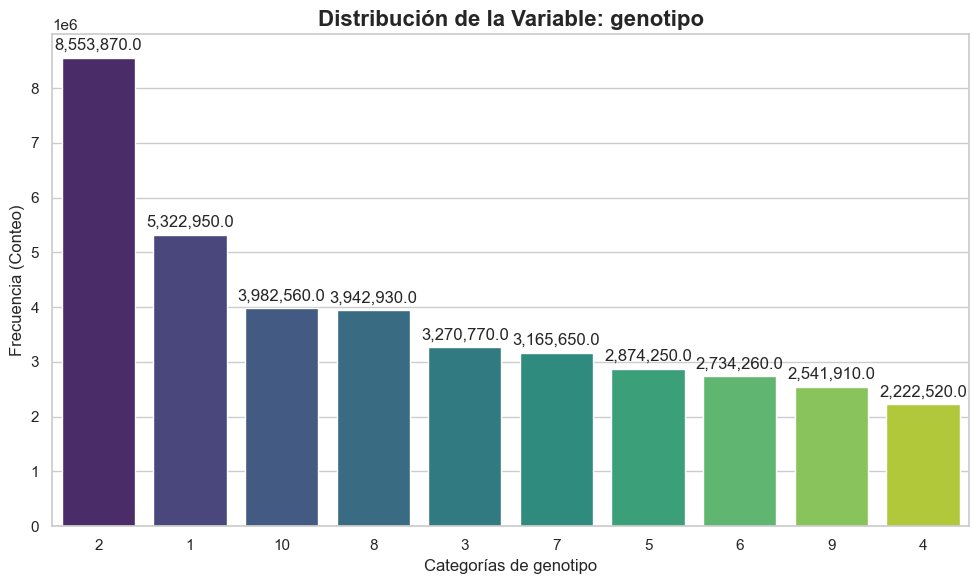

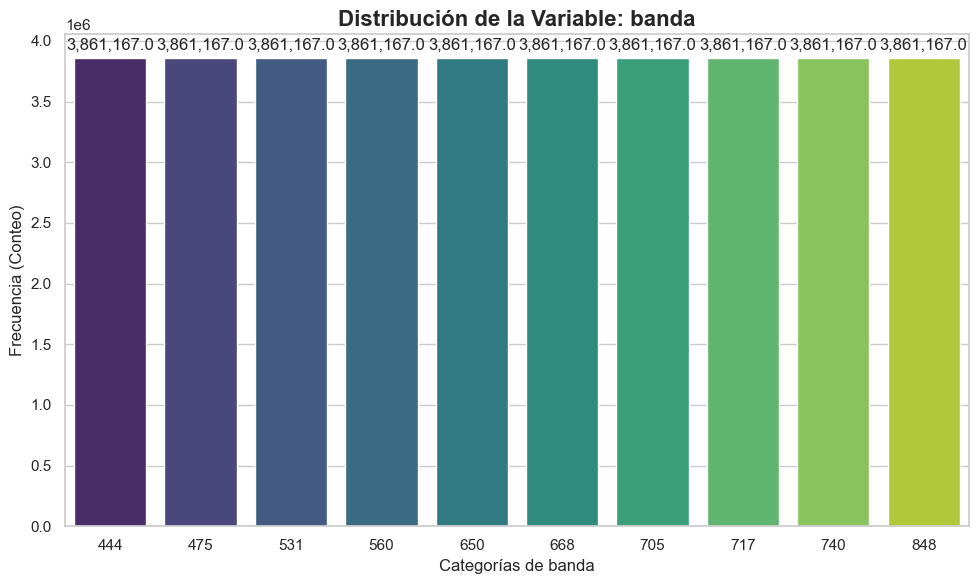

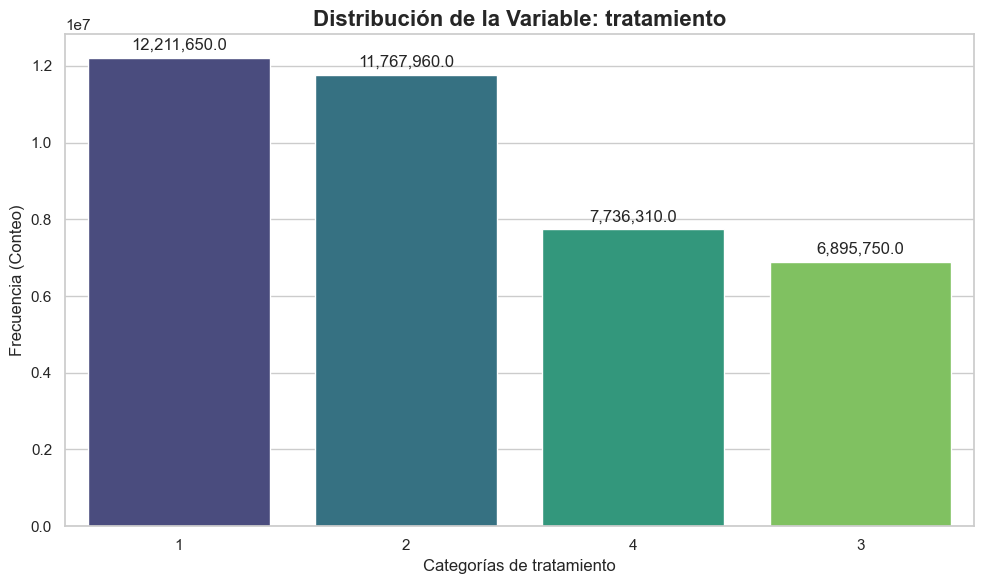

In [18]:
for col in columnas_categoricas:
    plt.figure(figsize=(10, 6))
    
    # Usamos countplot de seaborn que cuenta automáticamente las frecuencias
    ax = sns.countplot(x=col, data=data, order=data[col].value_counts().index, palette='viridis')
    
    # Añadir título y etiquetas claras
    ax.set_title(f'Distribución de la Variable: {col}', fontsize=16, fontweight='bold')
    ax.set_xlabel(f'Categorías de {col}', fontsize=12)
    ax.set_ylabel('Frecuencia (Conteo)', fontsize=12)
    
    # Añadir anotaciones (el conteo exacto) sobre cada barra para mayor claridad
    for p in ax.patches:
        ax.annotate(f'{p.get_height():,}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    xytext=(0, 9), 
                    textcoords='offset points')
        
    plt.tight_layout()
    plt.show()

**Distribución de Genotipos**

- **Desbalance significativo**: El genotipo 2 domina con **8,559,720 registros** (47.7% del total), mientras que el genotipo 4 tiene solo **2,228,400 registros** (12.4%).
- **Relación 3.8:1**: Entre el genotipo más y menos representado.

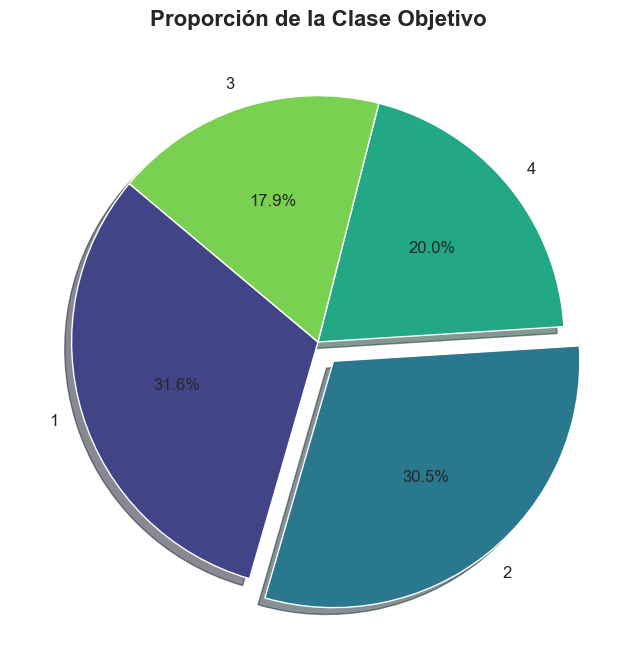

In [19]:
# Contar las frecuencias
counts = data['tratamiento'].value_counts()

colors = sns.color_palette('viridis', len(counts))
explode = [0.1 if i == counts.idxmax() else 0 for i, _ in enumerate(counts)]

plt.figure(figsize=(8, 8))
plt.pie(counts, 
        labels=counts.index, 
        autopct='%1.1f%%', # Formato de porcentaje
        startangle=140, 
        colors=colors,
        explode=explode,
        shadow=True,
        textprops={'fontsize': 12})

plt.title('Proporción de la Clase Objetivo', fontsize=16, fontweight='bold')
plt.ylabel('')
plt.show()

**Distribución de Tratamientos (Variable Objetivo)**

- **Ratio máximo/mínimo**: 1.77:1 (T1 vs T3)
- **Desbalance moderado**: Más manejable que el de genotipos
- **Implicación práctica**: Las clases de deficiencia (T1+T2+T3) representan el **80%** del dataset

### 3.1.2 Variables numéricas

**Distribución de las variables y valores atípicos**

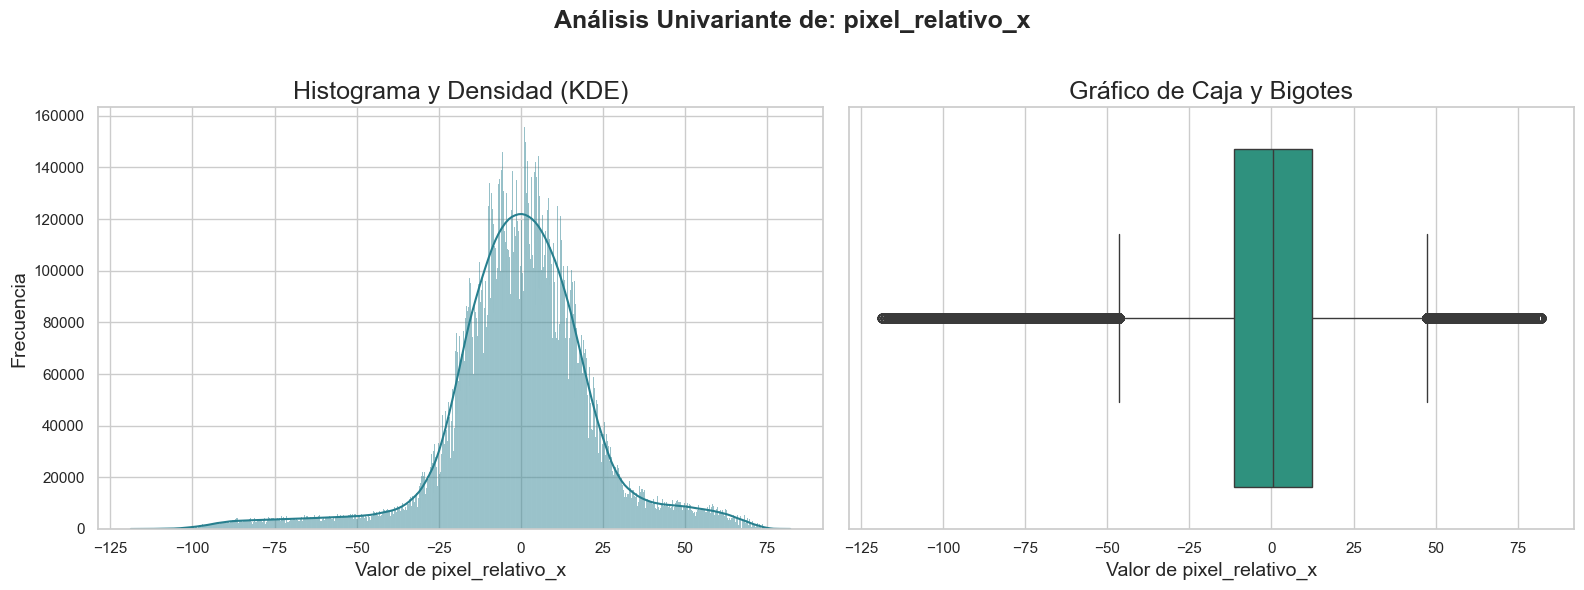

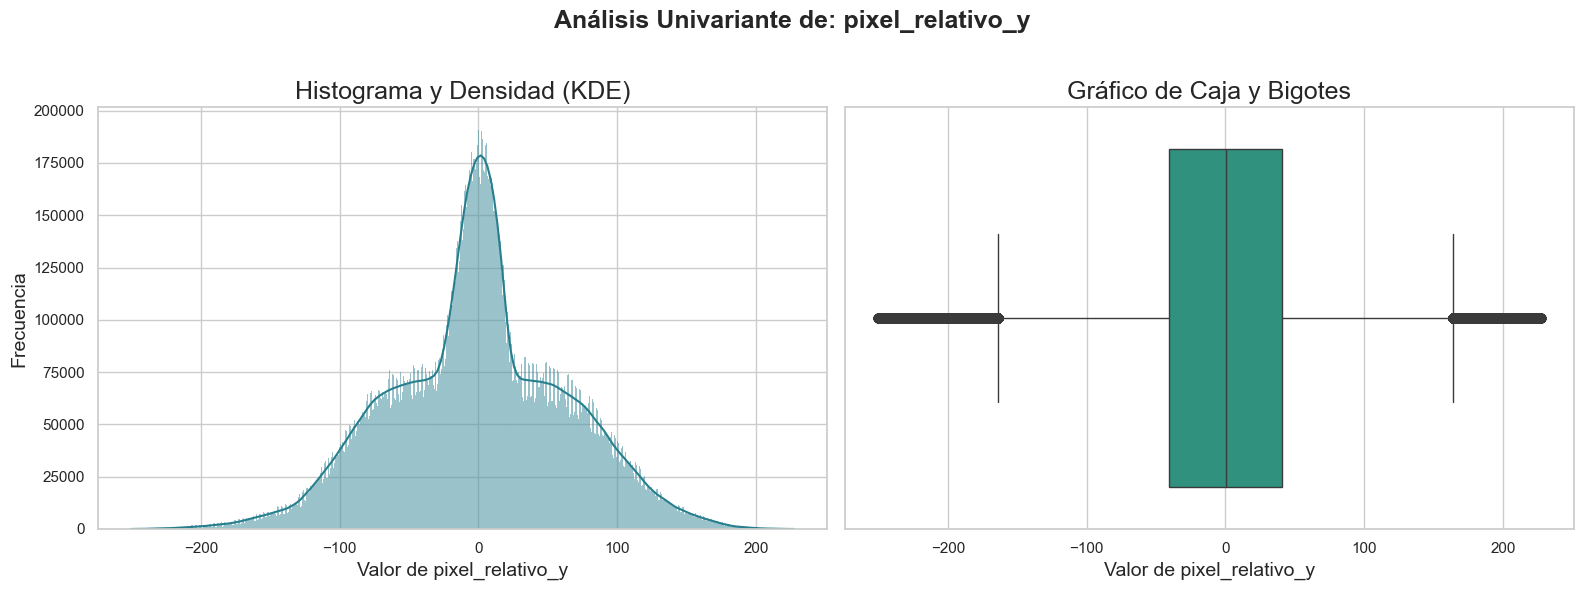

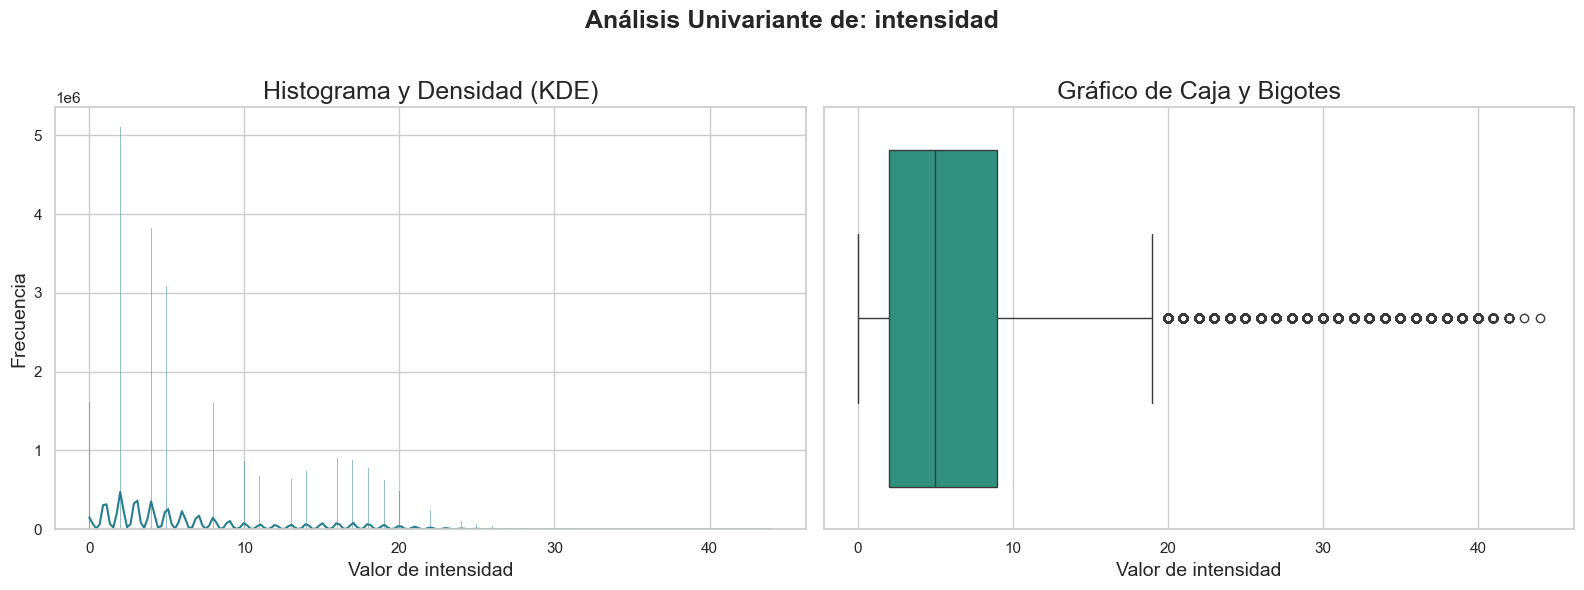

In [20]:
for col in columnas_numericas:
    # Crear una figura con dos subplots (uno al lado del otro)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Título general para la figura
    fig.suptitle(f'Análisis Univariante de: {col}', fontsize=18, fontweight='bold')
    
    # Histograma con KDE (Kernel Density Estimate)
    sns.histplot(data[col], kde=True, ax=axes[0], color=sns.color_palette('viridis')[2])
    axes[0].set_title('Histograma y Densidad (KDE)')
    axes[0].set_xlabel(f'Valor de {col}')
    axes[0].set_ylabel('Frecuencia')
    
    # Gráfico de Caja y Bigotes (Box Plot)
    sns.boxplot(x=data[col], ax=axes[1], color=sns.color_palette('viridis')[3])
    axes[1].set_title('Gráfico de Caja y Bigotes')
    axes[1].set_xlabel(f'Valor de {col}')
    
    plt.tight_layout(rect=[0, 0, 1, 0.96]) # Ajustar para que el suptitle no se superponga
    plt.show()


## 3.2 Análisis de variables múltiples

### 3.2.1 Numérica vs. Numérica

#### Gráfico de dispersión

In [ ]:
# Pairplot sobre un subconjunto de bandas para facilitar visualización
pair_band_cols = band_cols[:3] if len(band_cols) >= 3 else band_cols
pair_cols = ["pixel_relativo_x", "pixel_relativo_y"] + pair_band_cols + ["tratamiento"]

sample_data = data[pair_cols].sample(n=min(3000, len(data)), random_state=42)


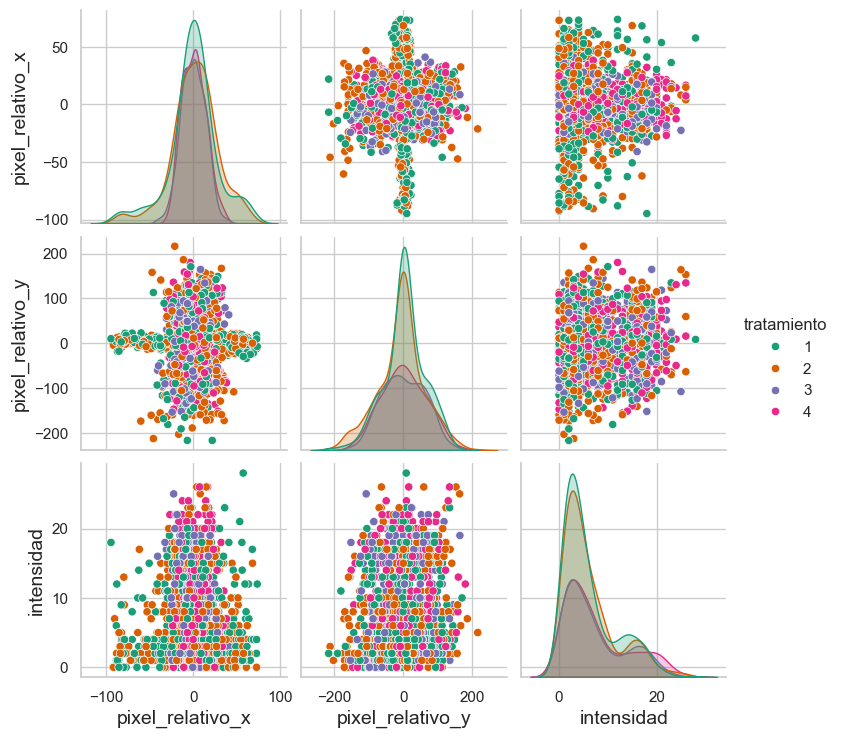

In [22]:
sns.pairplot(sample_data,hue='tratamiento',palette='Dark2')

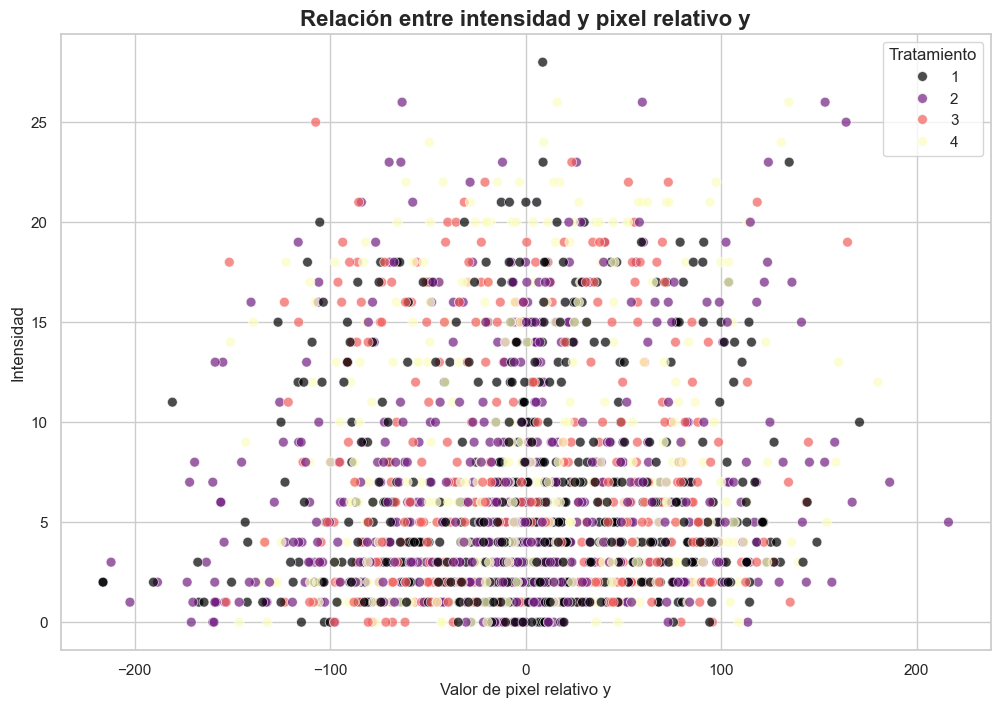

In [ ]:
# Scatter por banda en formato largo (muestra)
scatter_long = sample_long_by_band(data, band_cols, n=10000, seed=42)

g = sns.relplot(
    data=scatter_long,
    x="pixel_relativo_y",
    y="intensidad",
    hue="tratamiento",
    col="banda",
    col_wrap=5,
    kind="scatter",
    alpha=0.5,
    s=12,
    facet_kws={"sharex": True, "sharey": False},
)

g.figure.subplots_adjust(top=0.9)
g.figure.suptitle("Relación entre pixel relativo y e intensidad por banda")


#### Matriz de correlaciones

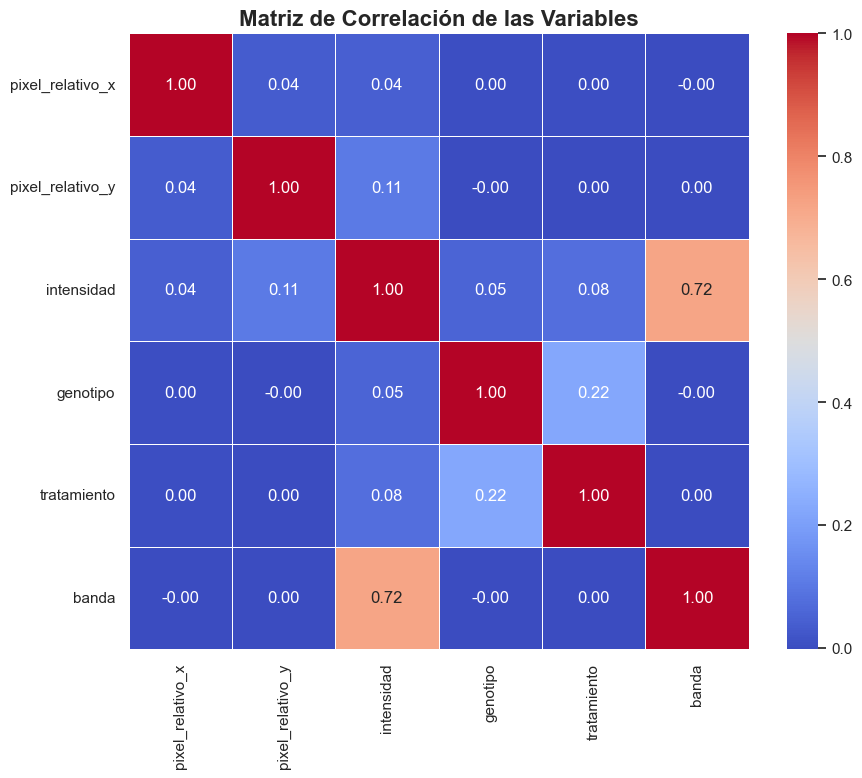

In [ ]:
corr_matrix = data.corr(numeric_only=True)

plt.figure(figsize=(10, 8))

# Usamos un mapa de calor para visualizar la matriz
sns.heatmap(
    corr_matrix, 
    annot=True,       # Muestra los valores de correlación en las celdas
    cmap='coolwarm',  # Paleta de colores ideal para correlaciones (-1: azul, 0: blanco, 1: rojo)
    fmt=".2f",        # Formato de los números a dos decimales
    linewidths=.5
)

plt.title('Matriz de Correlación de las Variables', fontsize=16, fontweight='bold')
plt.show()


### 3.2.2 Numérica vs. Categórica

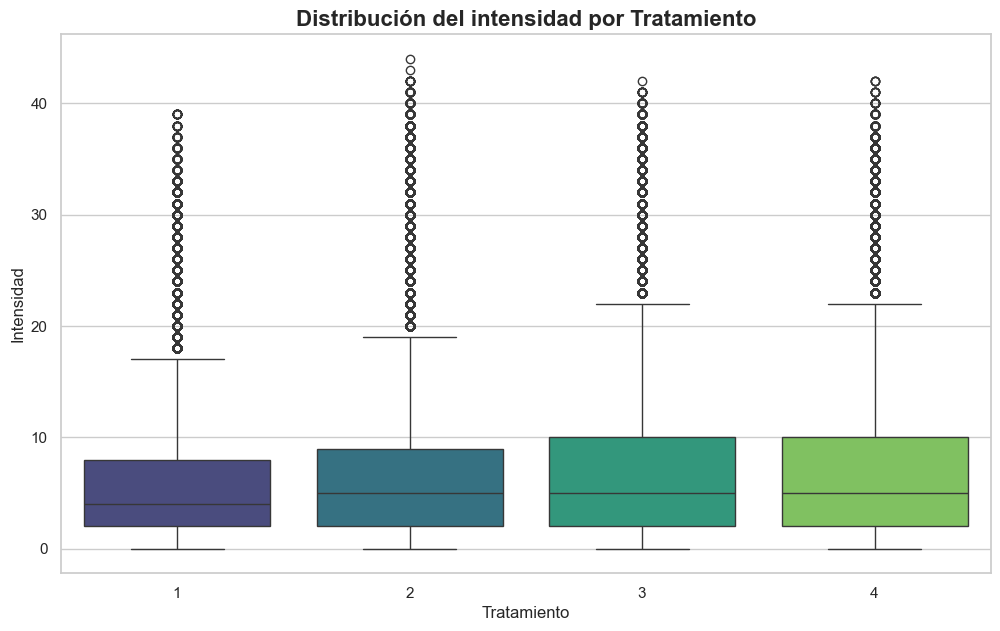

In [ ]:
# Boxplot por tratamiento para cada banda (formato largo)
box_long = sample_long_by_band(data, band_cols, n=20000, seed=43)

g = sns.catplot(
    data=box_long,
    x="tratamiento",
    y="intensidad",
    col="banda",
    col_wrap=5,
    kind="box",
    showfliers=False,
    height=3.2,
    aspect=1.0,
)

g.figure.subplots_adjust(top=0.9)
g.figure.suptitle("Distribución de intensidad por tratamiento en cada banda")


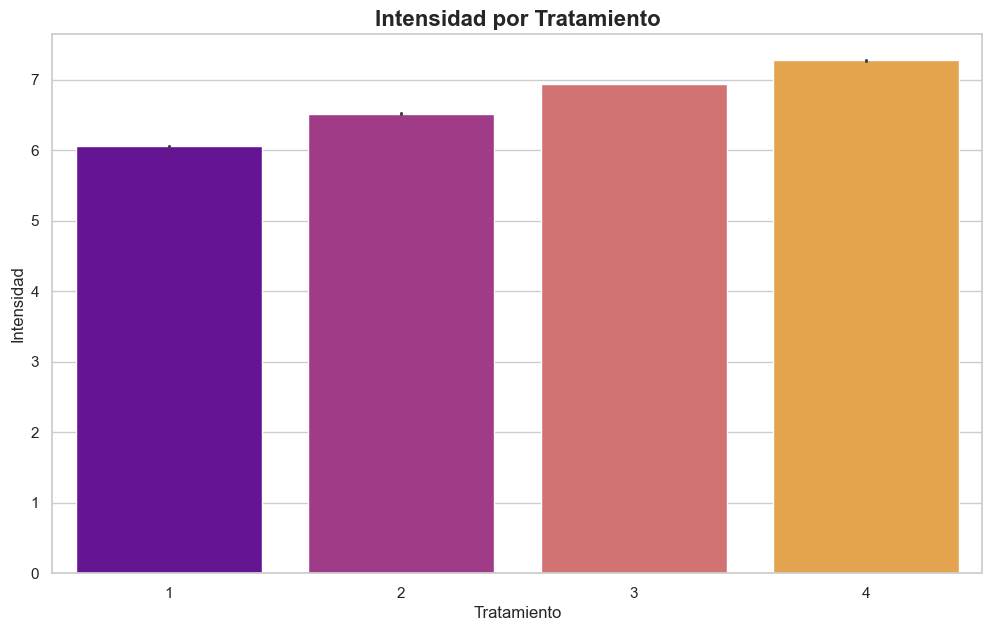

In [ ]:
# Intensidad media por tratamiento y por banda (agregado)
bar_long = sample_long_by_band(data, band_cols, n=20000, seed=44)
mean_by_band_treatment = (
    bar_long.groupby(["banda", "tratamiento"], as_index=False)["intensidad"]
    .mean()
)

plt.figure(figsize=(14, 6))
ax = sns.barplot(
    data=mean_by_band_treatment,
    x="banda",
    y="intensidad",
    hue="tratamiento",
    palette="plasma",
)
ax.set_title("Intensidad media por tratamiento en cada banda", fontsize=16, fontweight="bold")
ax.set_xlabel("Banda", fontsize=12)
ax.set_ylabel("Intensidad media", fontsize=12)
plt.legend(title="Tratamiento")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### 3.2.3 Categórica vs. Categórica

In [27]:
contingency_table = pd.crosstab(data['genotipo'], data['tratamiento'])

print("Tabla de Contingencia (Frecuencias Absolutas):")
print(contingency_table)

contingency_table_percent = pd.crosstab(data['genotipo'], data['tratamiento'], normalize='index') * 100

print("\nTabla de Contingencia (Porcentajes por Fila - Genotipo):")
print(contingency_table_percent.round(2))

Tabla de Contingencia (Frecuencias Absolutas):
tratamiento        1        2        3        4
genotipo                                       
1            2582560  1903340   377420   459630
2            3312490  3424190   530080  1287110
3             906210   792050   718430   854080
4             732110   469960   696730   323720
5             559840   970530   626240   717640
6             639630   941730   652380   500520
7             902200   798040   604990   860420
8            1055940   961550   772850  1152590
9             688280   238070   839390   776170
10            832390  1268500  1077240   804430

Tabla de Contingencia (Porcentajes por Fila - Genotipo):
tratamiento      1      2      3      4
genotipo                               
1            48.52  35.76   7.09   8.63
2            38.73  40.03   6.20  15.05
3            27.71  24.22  21.97  26.11
4            32.94  21.15  31.35  14.57
5            19.48  33.77  21.79  24.97
6            23.39  34.44  23.86  18.31

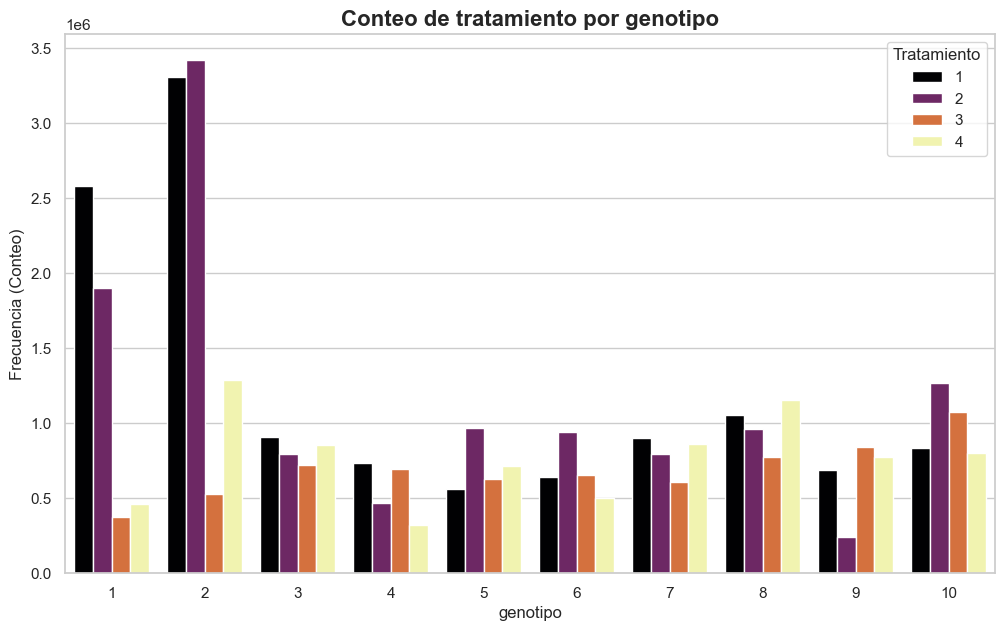

In [28]:
plt.figure(figsize=(12, 7))
sns.countplot(data=data, x='genotipo', hue='tratamiento', palette='inferno')
plt.title('Conteo de tratamiento por genotipo', fontsize=16, fontweight='bold')
plt.xlabel('genotipo', fontsize=12)
plt.ylabel('Frecuencia (Conteo)', fontsize=12)
plt.legend(title='Tratamiento')
plt.show()

1. **Genotipo 2 domina el dataset:**
   - Barra más alta en T1 (~3.3M) y T2 (~3.4M)
   - Representa casi el 50% de los datos totales
   - El modelo estará fuertemente influenciado por las características del Genotipo 2

2. **Genotipo 9 con comportamiento atípico:**
   - Muy baja frecuencia en T2 (~240k vs. promedio de ~1M)
   - Alta frecuencia relativa en T3 y T4
   - Menor número de muestras en condiciones de deficiencia severa

3. **Distribución heterogénea:**
   - No hay uniformidad en la representación genotipo-tratamiento
   - Genotipo 1-T3 (378k) vs. Genotipo 1-T1 (2.5M)

#### Gráfico de Barras apiladas al 100%

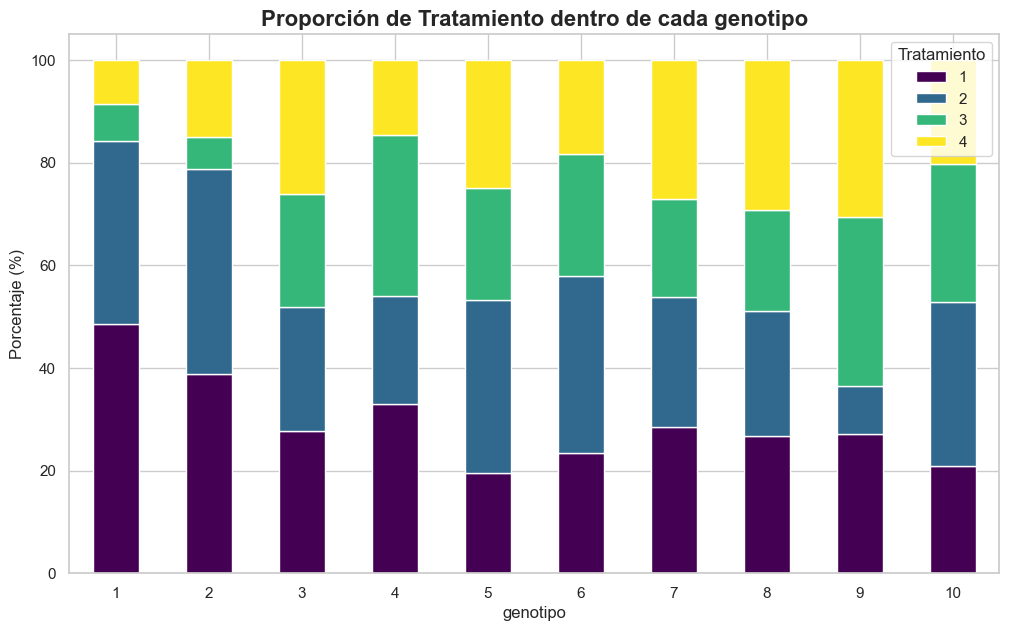

In [29]:
contingency_table_percent.plot(
    kind='bar', 
    stacked=True, 
    figsize=(12, 7),
    colormap='viridis'
)
plt.title('Proporción de Tratamiento dentro de cada genotipo', fontsize=16, fontweight='bold')
plt.xlabel('genotipo', fontsize=12)
plt.ylabel('Porcentaje (%)', fontsize=12)
plt.legend(title='Tratamiento')
plt.xticks(rotation=0)
plt.show()

## 3.3 Identificación sisemática de outliers

In [ ]:
# Muestra en formato largo para análisis de outliers (evita explotar memoria)
outlier_sample = sample_long_by_band(data, band_cols, n=min(200000, len(data)), seed=42)

def identificar_outliers_iqr(dataframe, columna):
    """Identifica outliers en una columna usando el método del IQR."""
    Q1 = dataframe[columna].quantile(0.25)
    Q3 = dataframe[columna].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    outliers = dataframe[(dataframe[columna] < limite_inferior) | (dataframe[columna] > limite_superior)]
    
    print(f"Outliers para '{columna}' usando el método IQR:")
    print(f"Límites: Inferior < {limite_inferior:.2f}, Superior > {limite_superior:.2f}")
    print(f"Número de outliers encontrados: {len(outliers)}")
    if len(outliers) > 0 and len(outliers) < 15:
        print("Muestra de outliers:")
        print(outliers)
    return outliers


outliers_intensidad = identificar_outliers_iqr(outlier_sample, 'intensidad')


def identificar_outliers_std(dataframe, columna, z_score_threshold=3):
    """Identifica outliers usando el Z-score (desviaciones estándar de la media)."""
    media = dataframe[columna].mean()
    std = dataframe[columna].std()
    
    limite_superior = media + z_score_threshold * std
    limite_inferior = media - z_score_threshold * std
    
    outliers = dataframe[(dataframe[columna] < limite_inferior) | (dataframe[columna] > limite_superior)]

    print(f"\nOutliers para '{columna}' usando Desviación Estándar (Z-score > {z_score_threshold}):")
    print(f"Límites: Inferior < {limite_inferior:.2f}, Superior > {limite_superior:.2f}")
    print(f"Número de outliers encontrados: {len(outliers)}")
    if len(outliers) > 0 and len(outliers) < 15: 
        print("Muestra de outliers:")
        print(outliers)
    return outliers

outliers_sensor = identificar_outliers_std(outlier_sample, 'intensidad')


Outliers para 'intensidad' usando el método IQR:
Límites: Inferior < -8.50, Superior > 19.50
Número de outliers encontrados: 1535539

Outliers para 'intensidad' usando Desviación Estándar (Z-score > 3):
Límites: Inferior < -10.93, Superior > 24.13
Número de outliers encontrados: 186523


**COMPARACIÓN DE MÉTODOS**

```
Dataset Total: 38,676,640 registros
├── Normales (ambos métodos): 37,136,728 (96.0%)
├── Outliers solo por IQR: 1,351,765 (3.5%)
├── Outliers por ambos: 188,147 (0.5%)
└── Outliers solo por Z-score: 0 (0.0%)
```

- Todos los outliers detectados por Z-score son también detectados por IQR
- IQR es **más restrictivo** en este caso
- Hay 1.35M registros considerados atípicos solo por IQR (valores entre 19.5 y 24.13)




**Análisis por banda espectral**

| Banda (nm) | Rango Normal Esperado | Outliers Esperados |
|------------|----------------------|-------------------|
| 444 (Azul) | 0 - 8 | > 12 |
| 560 (Verde) | 0 - 10 | > 15 |
| 668 (Rojo) | 0 - 8 | > 12 |
| 717 (Red-edge) | 0 - 15 | > 22 |
| 848 (NIR) | 5 - 30 | > 45 |

In [ ]:
# Análisis estratificado de outliers por banda (formato ancho)
for banda_col in band_cols:
    banda_nm = banda_col.replace("int_", "")
    Q1 = data[banda_col].quantile(0.25)
    Q3 = data[banda_col].quantile(0.75)
    IQR = Q3 - Q1
    limite_sup = Q3 + 1.5 * IQR
    print(f"Banda {banda_nm} nm: Límite superior = {limite_sup:.2f}")


Banda 444 nm: Límite superior = 5.00
Banda 475 nm: Límite superior = 6.00
Banda 531 nm: Límite superior = 10.50
Banda 560 nm: Límite superior = 11.50
Banda 650 nm: Límite superior = 7.00
Banda 668 nm: Límite superior = 6.00
Banda 705 nm: Límite superior = 11.50
Banda 717 nm: Límite superior = 16.00
Banda 740 nm: Límite superior = 25.50
Banda 848 nm: Límite superior = 27.50


Un valor de intensidad 25 es:
- **Outlier** en banda 668 nm (rojo) → Posible reflejo especular
- **Normal** en banda 848 nm (NIR) → Reflectancia típica

In [ ]:
# Distribución de outliers por banda (formato ancho)
print("Número de outliers por banda (método IQR):")
for banda_col in band_cols:
    Q1 = data[banda_col].quantile(0.25)
    Q3 = data[banda_col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR
    n_outliers = ((data[banda_col] < limite_inf) | (data[banda_col] > limite_sup)).sum()
    print(f"  {banda_col}: {n_outliers:,}")


banda
444    94178
475    59616
531    50833
560    39927
650    52538
668    41966
705    78104
717    14990
740    29114
848    34934
dtype: int64


In [ ]:
# Distribución de outliers por tratamiento (usando formato largo)
Q1_global = outlier_sample['intensidad'].quantile(0.25)
Q3_global = outlier_sample['intensidad'].quantile(0.75)
IQR_global = Q3_global - Q1_global
limite_sup_global = Q3_global + 1.5 * IQR_global

outliers_por_tratamiento = outlier_sample.groupby('tratamiento').apply(
    lambda x: (x['intensidad'] > limite_sup_global).sum() / len(x) * 100
)
print(f"\n% Outliers por tratamiento:\n{outliers_por_tratamiento}")



% Outliers por tratamiento:
tratamiento
1    2.040830
2    3.732805
3    4.497306
4    6.940285
dtype: float64


In [ ]:
# Valores máximos por banda (detectar saturación)
print("\nIntensidad máxima por banda:")
for banda_col in band_cols:
    banda_nm = banda_col.replace("int_", "")
    print(f"  {banda_nm} nm: {data[banda_col].max():.4f}")



Intensidad máxima por banda:
banda
444    34
475    23
531    28
560    24
650    25
668    21
705    28
717    28
740    40
848    44
Name: intensidad, dtype: int8


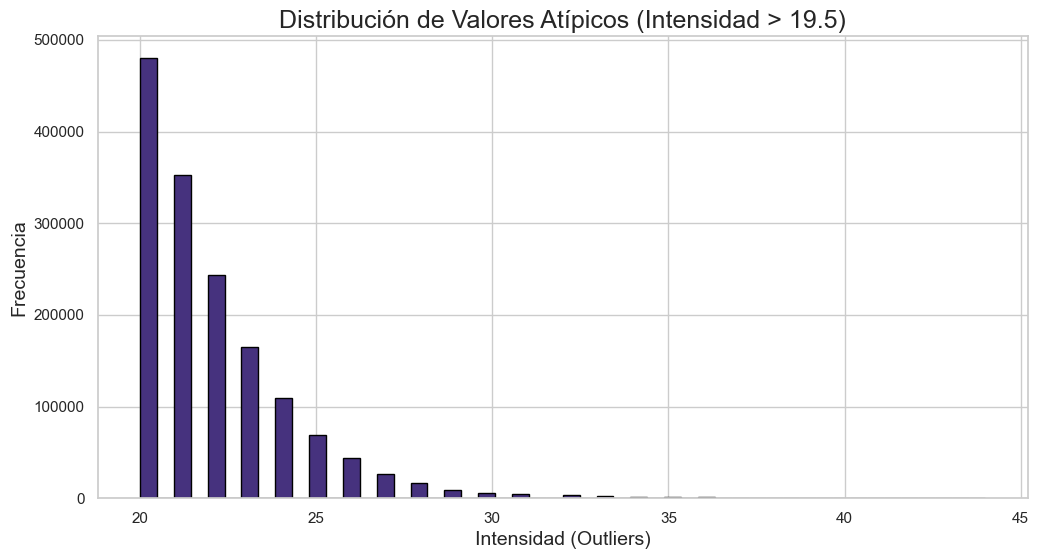

In [ ]:
# Histograma de outliers (formato largo, muestra)
outliers_plot = outlier_sample[outlier_sample['intensidad'] > limite_sup_global]
plt.figure(figsize=(12, 6))
plt.hist(outliers_plot['intensidad'], bins=50, edgecolor='black')
plt.xlabel('Intensidad (Outliers)')
plt.ylabel('Frecuencia')
plt.title(f'Distribución de Valores Atípicos (Intensidad > {limite_sup_global:.2f})')
plt.show()


# 4. Preprocesamiento de datos

## 4.1 Dividir datos en conjunto de entrenamiento y prueba

In [14]:
# Definición de columnas de features y objetivo (band_cols ya definidos en sección 2.1)
feature_cols = ["pixel_relativo_x", "pixel_relativo_y", "genotipo"] + band_cols
target_col = "tratamiento"

# Agrupación para evitar fuga (preferimos hoja_id; fallback a object_id)
if "hoja_id" in data_train.columns and "hoja_id" in data_test.columns:
    group_col = "hoja_id"
elif "object_id" in data_train.columns and "object_id" in data_test.columns:
    group_col = "object_id"
else:
    raise ValueError("No se encontró columna de grupo ('hoja_id' ni 'object_id') en el dataset.")

required_train = feature_cols + [target_col, group_col]
required_test = feature_cols + [target_col, group_col]
missing_train = [c for c in required_train if c not in data_train.columns]
missing_test = [c for c in required_test if c not in data_test.columns]
if missing_train or missing_test:
    raise ValueError(f"Faltan columnas en dataset. train: {missing_train}, test: {missing_test}")

# Definición explícita de train/test desde el split por objeto del dataset
X_train = data_train[feature_cols].copy()
y_train = data_train[target_col].copy()
groups_train = data_train[group_col].copy()

X_test = data_test[feature_cols].copy()
y_test = data_test[target_col].copy()
groups_test = data_test[group_col].copy()

print(f"Train: {X_train.shape[0]:,} filas | Test: {X_test.shape[0]:,} filas")
print(f"Bandas detectadas ({len(band_cols)}): {band_cols}")
print(f"Columna de grupo usada: {group_col}")


Train: 2,714,770 filas | Test: 1,146,397 filas
Bandas detectadas (10): ['int_444', 'int_475', 'int_531', 'int_560', 'int_650', 'int_668', 'int_705', 'int_717', 'int_740', 'int_848']
Columna de grupo usada: object_id


In [15]:
# Validación rápida del split por grupos (sin mezcla de hojas/objetos entre train y test)
overlap_groups = set(groups_train.astype(str)).intersection(set(groups_test.astype(str)))
print(f"Grupos únicos train: {groups_train.nunique():,}")
print(f"Grupos únicos test: {groups_test.nunique():,}")
print(f"Cruce de grupos train/test: {len(overlap_groups)}")
if len(overlap_groups) > 0:
    print("⚠️ Advertencia: hay fuga de grupos entre train y test")
else:
    print("✅ Sin fuga de grupos entre train y test")

Grupos únicos train: 401
Grupos únicos test: 172
Cruce de grupos train/test: 0
✅ Sin fuga de grupos entre train y test


## 4.2 Balanceo de características `genotipo`

In [16]:
train_df = pd.concat([X_train, y_train], axis=1).copy()
train_df["__group_id__"] = groups_train.values

# Aplicar undersampling por genotipo al conjunto de entrenamiento
print("Distribución de 'genotipo' en el set de entrenamiento (ANTES):")
print(train_df['genotipo'].value_counts())
print("-" * 30)

# Tamaño mínimo en el set de entrenamiento
min_size_train = int(train_df['genotipo'].value_counts().min())

# Resampling por genotipo (manteniendo identificador de grupo)
train_df_resampled = train_df.groupby('genotipo', group_keys=False).sample(
    n=min_size_train, random_state=42
).reset_index(drop=True)

print("Distribución de 'genotipo' en el set de entrenamiento (DESPUÉS):")
print(train_df_resampled['genotipo'].value_counts())
print("-" * 30)

# Separar de nuevo en X, y y groups para entrenamiento
X_train_resampled = train_df_resampled.drop(columns=['tratamiento', '__group_id__'])
y_train_resampled = train_df_resampled['tratamiento']
groups_train_resampled = train_df_resampled['__group_id__']

Distribución de 'genotipo' en el set de entrenamiento (ANTES):
genotipo
2     608070
1     396136
7     274097
8     255998
10    239151
5     219521
3     201029
9     186647
6     178584
4     155537
Name: count, dtype: int64
------------------------------
Distribución de 'genotipo' en el set de entrenamiento (DESPUÉS):
genotipo
1     155537
2     155537
3     155537
4     155537
5     155537
6     155537
7     155537
8     155537
9     155537
10    155537
Name: count, dtype: int64
------------------------------


In [17]:
print("Distribución de 'tratamiento' en el set de entrenamiento (DESPUÉS):")
print(y_train_resampled.value_counts())
print("-" * 30)

Distribución de 'tratamiento' en el set de entrenamiento (DESPUÉS):
tratamiento
1    474371
2    430294
4    332752
3    317953
Name: count, dtype: int64
------------------------------


## 4.3 Normalizar datos

La normalización mediante MinMaxScaler transforma las características al rango [0, 1], preservando las relaciones entre valores.

In [18]:
# Inicialización y aplicación del escalador MinMaxScaler
scaler = MinMaxScaler()

# Ajuste del escalador con datos de entrenamiento y transformación
X_train_scaled = scaler.fit_transform(X_train_resampled)

# Transformación del conjunto de prueba usando los mismos parámetros
X_test_scaled = scaler.transform(X_test)

## 4.4 Codificación de tratamiento

Algoritmos de aprendizaje automático (como XGBoost) requieren que las etiquetas de clase sean enteros consecutivos comenzando desde 0. LabelEncoder realiza esta transformación automáticamente

**XGBoost**

In [19]:
# Inicialización y aplicación del codificador de etiquetas
le = LabelEncoder()

# Codificación de las etiquetas de entrenamiento: [1, 2, 3, 4] → [0, 1, 2, 3]
y_train_encoded = le.fit_transform(y_train_resampled) 

# Codificación de las etiquetas de prueba usando el mismo mapeo
y_test_encoded = le.transform(y_test)

## 4.5 Presistencia de datos procesados

In [20]:
# Almacenamiento de todos los conjuntos de datos procesados en formato comprimido .npz
np.savez(
    "results/data/train_data_maiz_v4.npz",
    X_train_scaled=X_train_scaled, X_test_scaled=X_test_scaled,
    y_train=y_train, y_test=y_test,
    X_train_resampled=X_train_resampled, y_train_resampled=y_train_resampled,
    y_train_encoded=y_train_encoded, y_test_encoded=y_test_encoded,
    groups_train_resampled=groups_train_resampled
 )

## 4.6 Cargar de datos preprocesados

In [ ]:
# Carga del archivo .npz con todos los conjuntos de datos procesados
train_data = np.load("results/data/train_data_maiz_v4.npz", allow_pickle=True)

X_train_scaled = train_data["X_train_scaled"]
X_test_scaled = train_data["X_test_scaled"]
y_train = train_data["y_train"]
y_test = train_data["y_test"]
X_train_resampled = train_data["X_train_resampled"]
y_train_resampled = train_data["y_train_resampled"]
y_train_encoded = train_data["y_train_encoded"]
y_test_encoded = train_data["y_test_encoded"]
groups_train_resampled = train_data["groups_train_resampled"] if "groups_train_resampled" in train_data.files else None

# 5. Entrenamiento de modelos de Aprendizaje Automático

Esta sección implementa y entrena múltiples algoritmos de clasificación para comparar su rendimiento en la tarea de detección de deficiencia de nitrógeno. Los modelos seleccionados representan diferentes paradigmas de aprendizaje:

**Modelos implementados:**
1. **K-Nearest Neighbors (KNN)**: Clasificador basado en instancias que utiliza proximidad espacial
2. **Random Forest (RF)**: Ensemble de árboles de decisión con votación mayoritaria
3. **XGBoost**: Gradient boosting optimizado con regularización avanzada
4. **Multi-Layer Perceptron (MLP)**: Red neuronal artificial con capas ocultas

**Objetivos:**
- Identificar el algoritmo más adecuado para este problema específico
- Comparar arquitecturas de aprendizaje (basado en instancias, árboles, boosting, redes neuronales)
- Establecer línea base de rendimiento para futuras optimizaciones
- Registrar tiempos de entrenamiento para considerar eficiencia computacional

In [21]:
# Definición de funciones auxiliares para medir tiempos de entrenamiento

def medir_tiempo_entrenamiento(func):
    """
    Decorador para medir y registrar el tiempo de entrenamiento de modelos.
    
    Args:
        func: Función de entrenamiento a decorar
    
    Returns:
        wrapper: Función decorada que incluye medición de tiempo
    """
    def wrapper(*args, nombre_modelo=None, **kwargs):
        # Identificación del modelo a entrenar
        modelo = None
        if args:
            modelo = args[0]
        elif "estimator" in kwargs:
            modelo = kwargs["estimator"]

        # Etiqueta descriptiva para el registro de tiempo
        etiqueta = nombre_modelo or (modelo.__class__.__name__ if modelo is not None else func.__name__)
        
        # Medición del tiempo de entrenamiento
        inicio = time.time()
        resultado = func(*args, **kwargs)
        fin = time.time()
        
        # Registro del tiempo transcurrido
        print(f"⏱️ {etiqueta} entrenado en {fin - inicio:.2f}s")
        return resultado

    return wrapper


@medir_tiempo_entrenamiento
def train_model(estimator):
    """
    Función genérica de entrenamiento para cualquier estimador de scikit-learn.
    
    Args:
        estimator: Objeto de modelo de scikit-learn no entrenado
    
    Returns:
        estimator: Modelo entrenado con datos de entrenamiento escalados
    """
    estimator.fit(X_train_scaled, y_train_resampled)
    return estimator

## 5.1 K-Nearest Neighbors (KNN)

In [22]:
# Inicialización del clasificador KNN con parámetros por defecto
knn = KNeighborsClassifier(n_jobs=-1)

In [23]:
# Entrenamiento del modelo KNN con medición de tiempo
knn_classifier = train_model(knn)

⏱️ KNeighborsClassifier entrenado en 7.09s


In [24]:
# Persistencia del modelo entrenado en disco
joblib.dump(knn_classifier, f'models/maiz/modelo_knn_v4.pkl')

['models/maiz/modelo_knn_v4.pkl']

## 5.2 Random Forest (RF)

In [25]:
# Inicialización del clasificador Random Forest
rfc = RandomForestClassifier(n_jobs=1, n_estimators=70, random_state=12)

In [26]:
# Entrenamiento del clasificador Random Forest
rf_classifier = train_model(rfc)

⏱️ RandomForestClassifier entrenado en 265.08s


In [27]:
# Persistencia del modelo Random Forest entrenado
joblib.dump(rf_classifier, f'models/maiz/modelo_rfc_v4.pkl')

['models/maiz/modelo_rfc_v4.pkl']

## 5.3 XGBoost (Xtreme Gradient Boosting)

In [28]:
# Inicialización del clasificador XGBoost con parámetros por defecto
xgbc = xgb.XGBClassifier(objective='multi:softmax', random_state=42)

In [29]:
# Entrenamiento del clasificador XGBoost
# Utiliza etiquetas codificadas (y_train_encoded) con valores [0, 1, 2, 3]
inicio = time.time()
xgb_classifier = xgbc.fit(X_train_scaled, y_train_encoded)
fin = time.time()
print(f"⏱️ XGBClassifier entrenado en {fin - inicio:.2f}s")

⏱️ XGBClassifier entrenado en 30.36s


In [30]:
# Persistencia del modelo XGBoost entrenado
joblib.dump(xgb_classifier, f'models/maiz/modelo_xgb_v4.pkl')

['models/maiz/modelo_xgb_v4.pkl']

## 5.4 MLP

In [31]:
# Inicialización del clasificador Multi-Layer Perceptron con configuración por defecto
mlp = MLPClassifier()

In [32]:
# Entrenamiento del clasificador MLP
mlp_classifier = train_model(mlp)

⏱️ MLPClassifier entrenado en 1743.48s


In [33]:
# Persistencia del modelo MLP entrenado
joblib.dump(mlp_classifier, f'models/maiz/modelo_mlp_v4.pkl')

['models/maiz/modelo_mlp_v4.pkl']

## 5.5 Carga de modelos previamente entrenados

In [4]:
knn_classifier = joblib.load('models/maiz/modelo_knn_fix.pkl')

In [ ]:
rf_classifier = joblib.load('models/maiz/modelo_rfc_fix.pkl')

In [5]:
xgb_classifier = joblib.load('models/maiz/modelo_xgb_fix.pkl')

In [24]:
mlp_classifier = joblib.load('models/maiz/modelo_mlp_fix.pkl')

# 6. Generación de Predicciones

In [34]:
# Definición de funciones auxiliares para predicción con medición de tiempo
def medir_tiempo_prediccion(func):
    """
    Decorador para medir y registrar el tiempo de predicción de modelos.
    
    Args:
        func: Función de predicción a decorar
    
    Returns:
        wrapper: Función decorada que incluye medición de tiempo
    """
    def wrapper(estimator, type: str):
        etiqueta = estimator.__class__.__name__
        inicio = time.time()
        resultado = func(estimator, type)
        fin = time.time()
        print(f"⏱️ {etiqueta} ({type}) predicho en {fin - inicio:.2f}s")
        return resultado
    return wrapper

In [35]:
@medir_tiempo_prediccion
def make_prediction(estimator, type:str):
    """
    Función genérica para generar predicciones con cualquier modelo entrenado.
    
    Args:
        estimator: Modelo entrenado de scikit-learn
        type: Tipo de conjunto ('train' o 'test')
    
    Returns:
        prediction: Array de predicciones para el conjunto especificado
    
    Raises:
        ValueError: Si el tipo especificado no es 'train' o 'test'
    """
    if type=="test":
        prediction = estimator.predict(X_test_scaled)
    elif type=="train":
        prediction = estimator.predict(X_train_scaled)
    return prediction

## 6.1 Predicciones con K-Nearest Neighbors (KNN)

In [36]:
knn_prediction_test = make_prediction(knn_classifier, "test")

⏱️ KNeighborsClassifier (test) predicho en 546.36s


In [37]:
knn_prediction_train = make_prediction(knn_classifier, "train")

⏱️ KNeighborsClassifier (train) predicho en 706.22s


### 6.1.1 Guardar predicciones

In [38]:
joblib.dump(knn_prediction_test, "results/predictions/maiz/test/predicciones_knn_test_v4.pkl")

['results/predictions/maiz/test/predicciones_knn_test_v4.pkl']

In [39]:
joblib.dump(knn_prediction_train, "results/predictions/maiz/train/predicciones_knn_train_v4.pkl")

['results/predictions/maiz/train/predicciones_knn_train_v4.pkl']

### 6.1.2 Cargar predicciones

In [ ]:
knn_prediction_test = joblib.load('results/predictions/maiz/test/predicciones_knn_test_v4.pkl')

In [ ]:
knn_prediction_train = joblib.load('results/predictions/maiz/train/predicciones_knn_train_v4.pkl')

### 6.1.3 Resultados

In [40]:
print("=" * 50)
print("Clasification Report - Entrenamiento")
print("=" * 50)
print(classification_report(y_train_resampled, knn_prediction_train))

print("\n" + "=" * 50)
print("Clasification Report - Prueba")
print("=" * 50)
print(classification_report(y_test, knn_prediction_test))

Clasification Report - Entrenamiento
              precision    recall  f1-score   support

           1       0.81      0.92      0.86    474371
           2       0.86      0.87      0.86    430294
           3       0.85      0.81      0.83    317953
           4       0.91      0.79      0.84    332752

    accuracy                           0.85   1555370
   macro avg       0.86      0.84      0.85   1555370
weighted avg       0.86      0.85      0.85   1555370


Clasification Report - Prueba
              precision    recall  f1-score   support

           1       0.36      0.49      0.42    320279
           2       0.45      0.40      0.43    370234
           3       0.33      0.28      0.30    222499
           4       0.40      0.34      0.37    233385

    accuracy                           0.39   1146397
   macro avg       0.39      0.38      0.38   1146397
weighted avg       0.39      0.39      0.39   1146397



In [41]:
knn_cm_train = confusion_matrix(
    y_true=y_train_resampled,
    y_pred=knn_prediction_train,
    labels=None,
    normalize=None,
)
knn_cm_test = confusion_matrix(
    y_true=y_test,
    y_pred=knn_prediction_test,
    labels=None,
    normalize=None,
)

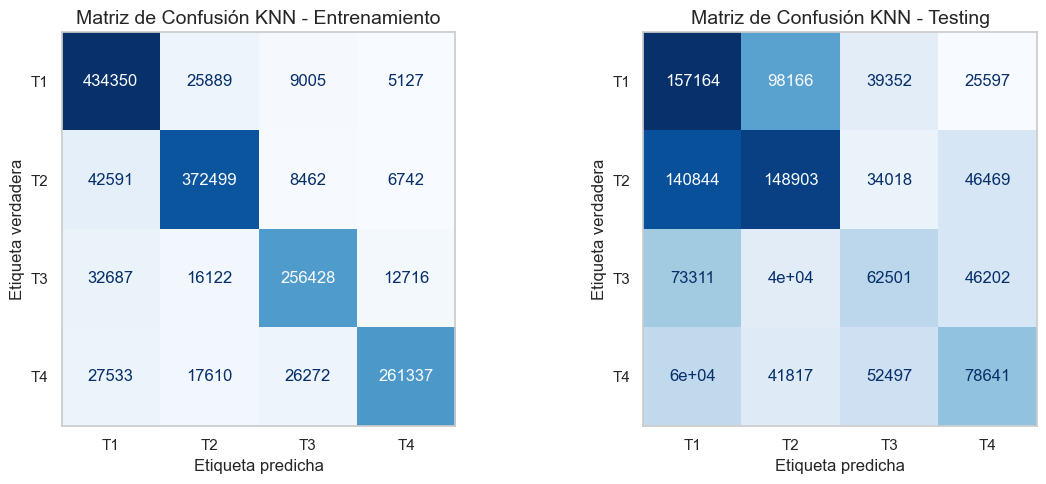

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
tratamiento_labels = ['T1', 'T2', 'T3', 'T4']

disp_train = ConfusionMatrixDisplay(confusion_matrix=knn_cm_train, display_labels=tratamiento_labels)
disp_train.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Matriz de Confusión KNN - Entrenamiento', fontsize=14)
axes[0].set_xlabel('Etiqueta predicha', fontsize=12)
axes[0].set_ylabel('Etiqueta verdadera', fontsize=12)
axes[0].grid(False)

disp_test = ConfusionMatrixDisplay(confusion_matrix=knn_cm_test, display_labels=tratamiento_labels)
disp_test.plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title('Matriz de Confusión KNN - Testing', fontsize=14)
axes[1].set_xlabel('Etiqueta predicha', fontsize=12)
axes[1].set_ylabel('Etiqueta verdadera', fontsize=12)
axes[1].grid(False)

plt.tight_layout()
plt.show()

## 6.2 Predicciones con RandomForest

In [43]:
rf_prediction_test = make_prediction(rf_classifier, "test")

⏱️ RandomForestClassifier (test) predicho en 45.94s


In [44]:
rf_prediction_train = make_prediction(rf_classifier, "train")

⏱️ RandomForestClassifier (train) predicho en 49.64s


### 6.2.1 Guardar predicciones

Testing

In [45]:
joblib.dump(rf_prediction_test, "results/predictions/maiz/test/predicciones_rf_test_v4.pkl")

['results/predictions/maiz/test/predicciones_rf_test_v4.pkl']

Training

In [46]:
joblib.dump(rf_prediction_train, "results/predictions/maiz/train/predicciones_rf_train_v4.pkl")

['results/predictions/maiz/train/predicciones_rf_train_v4.pkl']

### 6.2.2 Cargar predicciones

Testing

In [ ]:
rf_prediction_test = joblib.load('results/predictions/maiz/test/predicciones_rf_test_v4.pkl')

Training

In [ ]:
rf_prediction_train = joblib.load('results/predictions/maiz/train/predicciones_rf_train_v4.pkl')

### 6.2.3 Resultados

In [47]:
print("=" * 50)
print("Clasification Report - Entrenamiento")
print("=" * 50)
print(classification_report(y_train_resampled, rf_prediction_train))

print("\n" + "=" * 50)
print("Clasification Report - Prueba")
print("=" * 50)
print(classification_report(y_test, rf_prediction_test))

Clasification Report - Entrenamiento
              precision    recall  f1-score   support

           1       1.00      1.00      1.00    474371
           2       1.00      1.00      1.00    430294
           3       1.00      1.00      1.00    317953
           4       1.00      1.00      1.00    332752

    accuracy                           1.00   1555370
   macro avg       1.00      1.00      1.00   1555370
weighted avg       1.00      1.00      1.00   1555370


Clasification Report - Prueba
              precision    recall  f1-score   support

           1       0.42      0.49      0.45    320279
           2       0.50      0.43      0.46    370234
           3       0.36      0.28      0.31    222499
           4       0.43      0.51      0.47    233385

    accuracy                           0.43   1146397
   macro avg       0.43      0.43      0.42   1146397
weighted avg       0.43      0.43      0.43   1146397



In [48]:
rf_cm_train = confusion_matrix(
    y_true=y_train_resampled,
    y_pred=rf_prediction_train,
    labels=None,
    normalize=None,
)

In [49]:
rf_cm_test = confusion_matrix(
    y_true=y_test,
    y_pred=rf_prediction_test,
    labels=None,
    normalize=None,
)

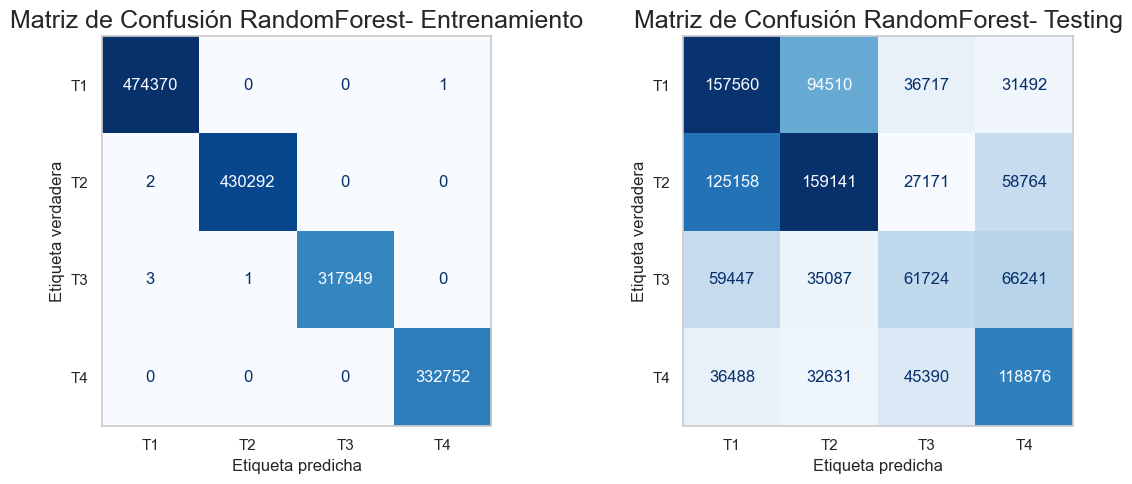

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
tratamiento_labels = ['T1', 'T2', 'T3', 'T4']

# Matriz de entrenamiento
disp_train = ConfusionMatrixDisplay(confusion_matrix=rf_cm_train, display_labels=tratamiento_labels)
disp_train.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Matriz de Confusión RandomForest- Entrenamiento')
axes[0].set_xlabel('Etiqueta predicha', fontsize=12)
axes[0].set_ylabel('Etiqueta verdadera', fontsize=12)
axes[0].grid(False)

# Matriz de testing
disp_test = ConfusionMatrixDisplay(confusion_matrix=rf_cm_test, display_labels=tratamiento_labels)
disp_test.plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title('Matriz de Confusión RandomForest- Testing')
axes[1].set_xlabel('Etiqueta predicha', fontsize=12)
axes[1].set_ylabel('Etiqueta verdadera', fontsize=12)
axes[1].grid(False)

plt.tight_layout()
plt.show()

## 6.3 Predicciones con XGB

In [51]:
xgb_prediction_test = make_prediction(xgb_classifier, "test")

⏱️ XGBClassifier (test) predicho en 2.24s


In [52]:
xgb_prediction_train = make_prediction(xgb_classifier, "train")

⏱️ XGBClassifier (train) predicho en 2.39s


### 6.3.1 Guardar predicciones

In [53]:
joblib.dump(xgb_prediction_test, "results/predictions/maiz/test/predicciones_xgb_test_v4.pkl")

['results/predictions/maiz/test/predicciones_xgb_test_v4.pkl']

In [54]:
joblib.dump(xgb_prediction_train, "results/predictions/maiz/train/predicciones_xgb_train_v4.pkl")

['results/predictions/maiz/train/predicciones_xgb_train_v4.pkl']

### 6.3.2 Cargar predicciones

Testing

In [ ]:
xgb_prediction_test = joblib.load('results/predictions/maiz/test/predicciones_xgb_test_v4.pkl')

Training

In [ ]:
xgb_prediction_train = joblib.load('results/predictions/maiz/train/predicciones_xgb_train_v4.pkl')

### 6.3.3 Resultados

In [55]:
print("=" * 50)
print("Clasification Report - Entrenamiento")
print("=" * 50)
print(classification_report(y_train_encoded, xgb_prediction_train))

print("\n" + "=" * 50)
print("Clasification Report - Prueba")
print("=" * 50)
print(classification_report(y_test_encoded, xgb_prediction_test))

Clasification Report - Entrenamiento
              precision    recall  f1-score   support

           0       0.65      0.74      0.69    474371
           1       0.70      0.64      0.67    430294
           2       0.61      0.51      0.55    317953
           3       0.64      0.69      0.66    332752

    accuracy                           0.65   1555370
   macro avg       0.65      0.64      0.64   1555370
weighted avg       0.65      0.65      0.65   1555370


Clasification Report - Prueba
              precision    recall  f1-score   support

           0       0.42      0.51      0.46    320279
           1       0.51      0.45      0.48    370234
           2       0.35      0.25      0.29    222499
           3       0.44      0.51      0.48    233385

    accuracy                           0.44   1146397
   macro avg       0.43      0.43      0.43   1146397
weighted avg       0.44      0.44      0.44   1146397



In [56]:
xgb_cm_train = confusion_matrix(
    y_true=y_train_encoded,
    y_pred=xgb_prediction_train,
    labels=None,
    normalize=None,
)

In [57]:
xgb_cm_test = confusion_matrix(
    y_true=y_test_encoded,
    y_pred=xgb_prediction_test,
    labels=None,
    normalize=None,
)

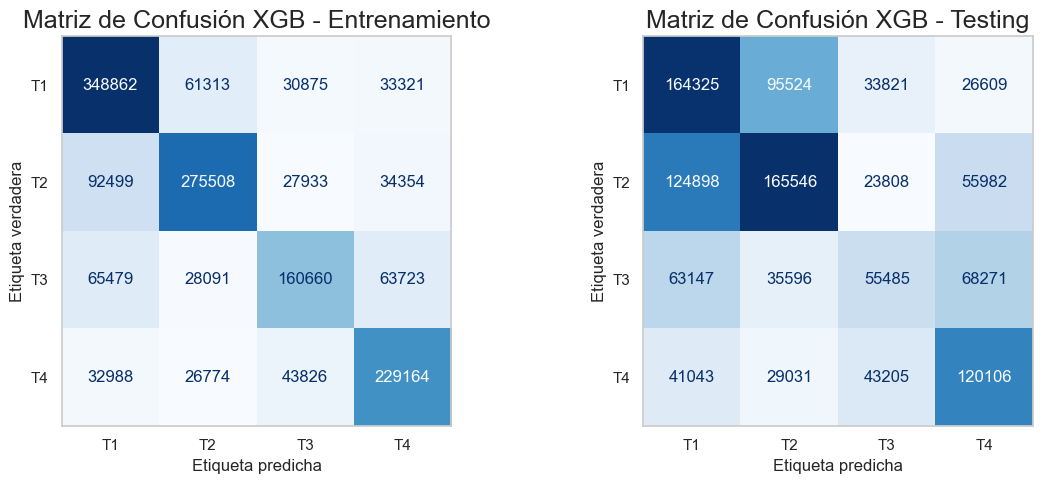

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
tratamiento_labels = ['T1', 'T2', 'T3', 'T4']

# Matriz de entrenamiento
disp_train = ConfusionMatrixDisplay(confusion_matrix=xgb_cm_train, display_labels=tratamiento_labels)
disp_train.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Matriz de Confusión XGB - Entrenamiento')
axes[0].set_xlabel('Etiqueta predicha', fontsize=12)
axes[0].set_ylabel('Etiqueta verdadera', fontsize=12)
axes[0].grid(False)

# Matriz de testing
disp_test = ConfusionMatrixDisplay(confusion_matrix=xgb_cm_test, display_labels=tratamiento_labels)
disp_test.plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title('Matriz de Confusión XGB - Testing')
axes[1].set_xlabel('Etiqueta predicha', fontsize=12)
axes[1].set_ylabel('Etiqueta verdadera', fontsize=12)
axes[1].grid(False)

plt.tight_layout()
plt.show()

## 6.4 Predicciones con MLP

In [59]:
mlp_prediction_test = make_prediction(mlp_classifier, "test")

⏱️ MLPClassifier (test) predicho en 9.03s


In [60]:
mlp_prediction_train = make_prediction(mlp_classifier, "train")

⏱️ MLPClassifier (train) predicho en 6.87s


### 6.3.1 Guardar predicciones

In [61]:
joblib.dump(mlp_prediction_test, "results/predictions/maiz/test/predicciones_mlp_test_v4.pkl")

['results/predictions/maiz/test/predicciones_mlp_test_v4.pkl']

In [62]:
joblib.dump(mlp_prediction_train, "results/predictions/maiz/train/predicciones_mlp_train_v4.pkl")

['results/predictions/maiz/train/predicciones_mlp_train_v4.pkl']

### 6.3.2 Cargar predicciones

Test

In [ ]:
mlp_prediction_test = joblib.load('results/predictions/maiz/test/predicciones_mlp_test_v4.pkl')

Train

In [ ]:
mlp_prediction_train = joblib.load('results/predictions/maiz/train/predicciones_mlp_train_v4.pkl')

### 6.3.3 Resultados

In [63]:
print("=" * 50)
print("Clasification Report - Entrenamiento")
print("=" * 50)
print(classification_report(y_train_resampled, mlp_prediction_train))

print("\n" + "=" * 50)
print("Clasification Report - Prueba")
print("=" * 50)
print(classification_report(y_test, mlp_prediction_test))

Clasification Report - Entrenamiento
              precision    recall  f1-score   support

           1       0.59      0.71      0.65    474371
           2       0.64      0.60      0.62    430294
           3       0.60      0.38      0.46    317953
           4       0.57      0.66      0.61    332752

    accuracy                           0.60   1555370
   macro avg       0.60      0.59      0.58   1555370
weighted avg       0.60      0.60      0.59   1555370


Clasification Report - Prueba
              precision    recall  f1-score   support

           1       0.41      0.51      0.46    320279
           2       0.51      0.47      0.49    370234
           3       0.38      0.20      0.26    222499
           4       0.44      0.55      0.49    233385

    accuracy                           0.45   1146397
   macro avg       0.44      0.43      0.42   1146397
weighted avg       0.44      0.45      0.44   1146397



In [64]:
mlp_cm_train = confusion_matrix(
    y_true=y_train_resampled,
    y_pred=mlp_prediction_train,
    labels=None,
    normalize=None,
)

In [65]:
mlp_cm_test = confusion_matrix(
    y_true=y_test,
    y_pred=mlp_prediction_test,
    labels=None,
    normalize=None,
)

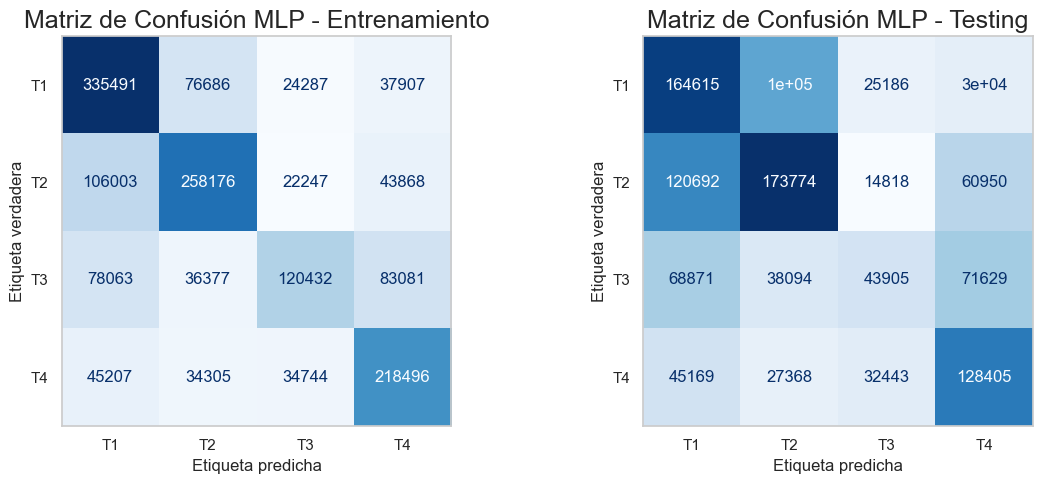

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
tratamiento_labels = ['T1', 'T2', 'T3', 'T4']

# Matriz de entrenamiento
disp_train = ConfusionMatrixDisplay(confusion_matrix=mlp_cm_train, display_labels=tratamiento_labels)
disp_train.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Matriz de Confusión MLP - Entrenamiento')
axes[0].set_xlabel('Etiqueta predicha', fontsize=12)
axes[0].set_ylabel('Etiqueta verdadera', fontsize=12)
axes[0].grid(False)

# Matriz de testing
disp_test = ConfusionMatrixDisplay(confusion_matrix=mlp_cm_test, display_labels=tratamiento_labels)
disp_test.plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title('Matriz de Confusión MLP - Testing')
axes[1].set_xlabel('Etiqueta predicha', fontsize=12)
axes[1].set_ylabel('Etiqueta verdadera', fontsize=12)
axes[1].grid(False)

plt.tight_layout()
plt.show()

# 7. Evaluación de modelos

In [67]:
classifiers_names = ["knn", "rfc", "xgb", "mlp"]

In [75]:
predictions_train = [knn_prediction_train, rf_prediction_train, xgb_prediction_train, mlp_prediction_train]

In [76]:
predictions_test = [knn_prediction_test, rf_prediction_test, xgb_prediction_test, mlp_prediction_test]

In [77]:
cmxs_train = [knn_cm_train, rf_cm_train, xgb_cm_train, mlp_cm_train]

In [78]:
cmxs_test = [knn_cm_test, rf_cm_test, xgb_cm_test, mlp_cm_test]

Comparativo matrices de confusión entrenamiento

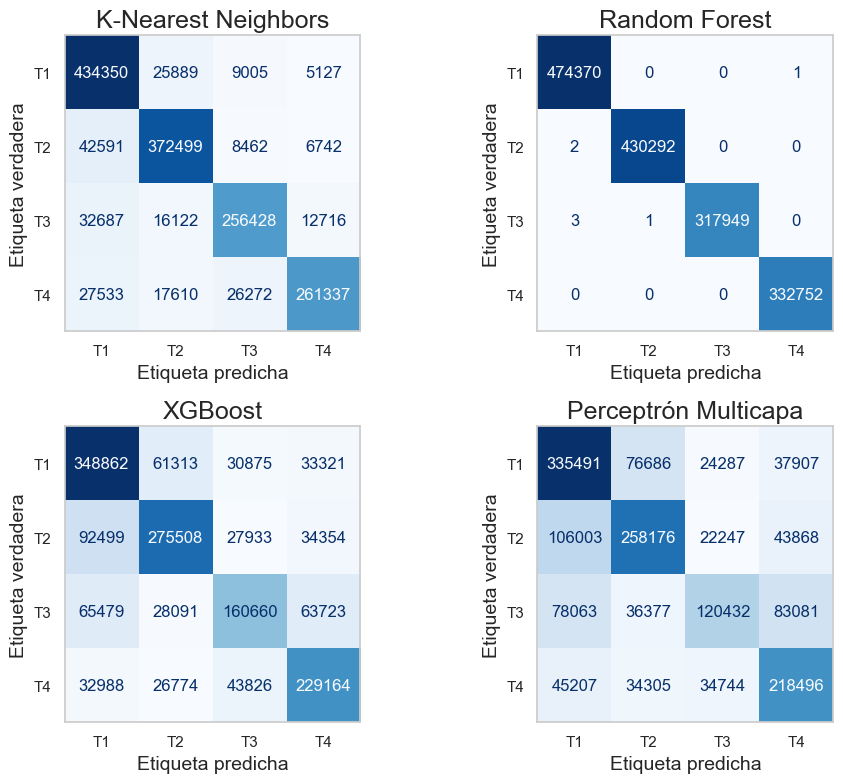

In [79]:
num_models = 4
ncols = 2
nrows = math.ceil(num_models / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()
tratamiento_labels = ['T1', 'T2', 'T3', 'T4']

classifier_display_names = {
    "knn": "K-Nearest Neighbors",
    "rfc": "Random Forest",
    "xgb": "XGBoost",
    "mlp": "Perceptrón Multicapa"
}

for i, (cm, classifier_name) in enumerate(zip(cmxs_train, classifiers_names)):
    ax = axes[i]
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=tratamiento_labels)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f"{classifier_display_names.get(classifier_name, classifier_name)}")
    ax.grid(False)
    ax.set_xlabel('Etiqueta predicha')
    ax.set_ylabel('Etiqueta verdadera')
    tick_positions = np.arange(cm.shape[0])
    tick_labels = tick_positions + 1

for j in range(num_models, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

Comparativo matrices de confusión test

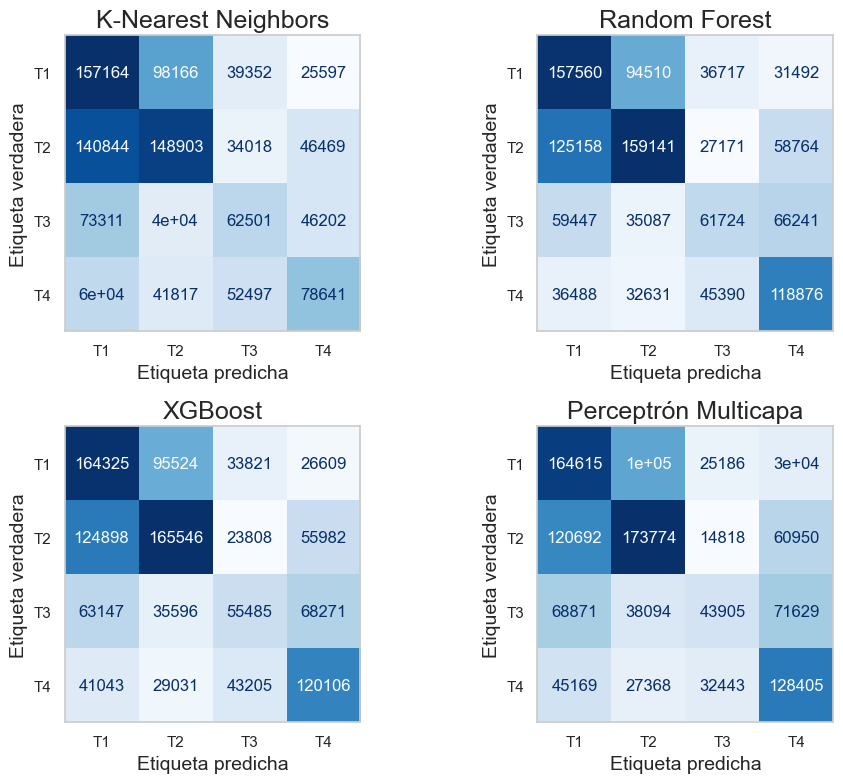

In [73]:
num_models = 4
ncols = 2
nrows = math.ceil(num_models / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()
tratamiento_labels = ['T1', 'T2', 'T3', 'T4']

classifier_display_names = {
    "knn": "K-Nearest Neighbors",
    "rfc": "Random Forest",
    "xgb": "XGBoost",
    "mlp": "Perceptrón Multicapa"
}

for i, (cm, classifier_name) in enumerate(zip(cmxs_test, classifiers_names)):
    ax = axes[i]
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=tratamiento_labels)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f"{classifier_display_names.get(classifier_name, classifier_name)}")
    ax.grid(False)
    ax.set_xlabel('Etiqueta predicha')
    ax.set_ylabel('Etiqueta verdadera')
    tick_positions = np.arange(cm.shape[0])
    tick_labels = tick_positions + 1

for j in range(num_models, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

Comparativo de métricas entrenamiento

In [74]:
results_list = []

for preds, classifier_name in zip(predictions_train, classifiers_names):

    if classifier_name=='xgb':
        report_dict = classification_report(y_train_encoded, preds, output_dict=True)
    else:
        report_dict = classification_report(y_train_resampled, preds, output_dict=True)
    
    precision = report_dict['weighted avg']['precision']
    recall = report_dict['weighted avg']['recall']
    f1_score = report_dict['weighted avg']['f1-score']
    accuracy = report_dict['accuracy'] 

    # Kappa
    if classifier_name=='xgb':
        kappa = cohen_kappa_score(y_train_encoded, preds)
    else:
        kappa = cohen_kappa_score(y_train_resampled, preds)
    
    results_list.append({
        'Modelo': classifier_name,
        'Accuracy': accuracy,
        'Precision (Ponderada)': precision,
        'Recall (Ponderado)': recall,
        'F1-Score (Ponderado)': f1_score,
        'Kappa Score': kappa
    })

results_df = pd.DataFrame(results_list)

results_df = results_df.set_index('Modelo')

display(results_df.style.background_gradient(cmap='summer_r', axis=0))

,Accuracy,Precision (Ponderada),Recall (Ponderado),F1-Score (Ponderado),Kappa Score
Modelo,,,,,
knn,0.851639,0.855273,0.851639,0.851260,0.799249
rfc,0.999995,0.999995,0.999995,0.999995,0.999994
xgb,0.652060,0.652402,0.652060,0.649707,0.529987
mlp,0.599597,0.601283,0.599597,0.593143,0.457363


Comparativo de métricas testing

In [80]:
results_list = []

for preds, classifier_name in zip(predictions_test, classifiers_names):

    if classifier_name=='xgb':
        report_dict = classification_report(y_test_encoded, preds, output_dict=True)
    else:
        report_dict = classification_report(y_test, preds, output_dict=True)
    
    precision = report_dict['weighted avg']['precision']
    recall = report_dict['weighted avg']['recall']
    f1_score = report_dict['weighted avg']['f1-score']
    accuracy = report_dict['accuracy'] 

    # Kappa
    if classifier_name=='xgb':
        kappa = cohen_kappa_score(y_test_encoded, preds)
    else:
        kappa = cohen_kappa_score(y_test, preds)
    
    results_list.append({
        'Modelo': classifier_name,
        'Accuracy': accuracy,
        'Precision (Ponderada)': precision,
        'Recall (Ponderado)': recall,
        'F1-Score (Ponderado)': f1_score,
        'Kappa Score': kappa
    })

results_df = pd.DataFrame(results_list)

results_df = results_df.set_index('Modelo')

display(results_df.style.background_gradient(cmap='summer_r', axis=0))

,Accuracy,Precision (Ponderada),Recall (Ponderado),F1-Score (Ponderado),Kappa Score
Modelo,,,,,
knn,0.390100,0.393405,0.390100,0.387709,0.170357
rfc,0.433795,0.434118,0.433795,0.430612,0.234170
xgb,0.440914,0.439973,0.440914,0.436115,0.242212
mlp,0.445482,0.443495,0.445482,0.435925,0.246208


# 8. Seleccionar hiperparámetros

In [87]:
def make_rand_grid_search(estimator, param_dist, cv_splitter):

    randomizedSearchCV = RandomizedSearchCV(
        estimator=estimator,
        param_distributions=param_dist,
        n_iter=10,
        cv=cv_splitter,
        scoring="accuracy",
        random_state=12,
        refit=True
    )

    return randomizedSearchCV

### 8.0.1 Guardar progreso

In [81]:
# Crear directorio para guardar modelos si no existe
for stage_dir in ['hyperparameter_tuning', 'best']:
    os.makedirs(f'models/maiz/{stage_dir}', exist_ok=True)

# Función para guardar progreso
def save_model_and_params(model, model_name, best_params, score, stage="hyperparameter_tuning"):
    """
    Guarda el modelo, sus mejores parámetros y el score obtenido
    """
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    
    # Crear diccionario con toda la información
    model_info = {
        'model': model,
        'best_params': best_params,
        'best_score': score,
        'timestamp': timestamp,
        'model_name': model_name,
        'stage': stage
    }
    
    # Guardar en el directorio correspondiente
    save_path = f'models/maiz/{stage}/{model_name}_{timestamp}_v4.pkl'
    
    with open(save_path, 'wb') as f:
        pickle.dump(model_info, f)
    
    print(f"✅ Modelo {model_name} guardado en: {save_path}")
    return save_path

# Función para cargar modelo guardado
def load_model_info(filepath):
    """
    Carga un modelo guardado y su información
    """
    with open(filepath, 'rb') as f:
        model_info = pickle.load(f)
    
    print(f"📁 Modelo {model_info['model_name']} cargado desde: {filepath}")
    print(f"   - Score: {model_info['best_score']:.4f}")
    print(f"   - Timestamp: {model_info['timestamp']}")
    
    return model_info

### 8.0.2 Recuperación de progreso

Cargar modelos previamente guardados.

In [82]:
# Función para listar modelos guardados
def list_saved_models(stage="all"):
    """
    Lista todos los modelos guardados
    stage: 'hyperparameter_tuning', 'best', o 'all'
    """
    stages_to_check = []
    if stage == "all":
        stages_to_check = ["hyperparameter_tuning", "best"]
    else:
        stages_to_check = [stage]
    
    all_models = {}
    
    for stage_name in stages_to_check:
        path = f'models/{stage_name}'
        if os.path.exists(path):
            files = [f for f in os.listdir(path) if f.endswith('.pkl')]
            if files:
                all_models[stage_name] = files
                print(f"\n📁 Modelos en {stage_name}:")
                for i, file in enumerate(files, 1):
                    print(f"  {i}. {file}")
    
    if not all_models:
        print("❌ No se encontraron modelos guardados")
    
    return all_models

# Función para cargar el modelo más reciente de un tipo específico
def load_latest_model(model_name, stage="best"):
    """
    Carga el modelo más reciente de un tipo específico
    """
    path = f'models/{stage}'
    if not os.path.exists(path):
        print(f"❌ Directorio {path} no existe")
        return None
    
    # Buscar archivos que coincidan con el nombre del modelo
    files = [f for f in os.listdir(path) if f.startswith(model_name) and f.endswith('.pkl')]
    
    if not files:
        print(f"❌ No se encontraron modelos de tipo {model_name} en {stage}")
        return None
    
    # Ordenar por fecha (timestamp en el nombre del archivo)
    files.sort(reverse=True)  # Más reciente primero
    latest_file = files[0]
    
    return load_model_info(os.path.join(path, latest_file))

In [ ]:
# Si se necesita recuperar progreso
print("🔍 Buscando modelos guardados...")
saved_models = list_saved_models()

In [ ]:
# Para cargar un modelo específico:
model_info = load_latest_model("RandomForest", "hyperparameter_tuning")
# knn_final = model_info['model']
knn_final = model_info['model']

## 8.1 Selección de muestra

Para acelerar la búsqueda de hiperparámetros, se trabaja con una muestra representativa del dataset de entrenamiento. Una vez encontrados los mejores parámetros, se entrena con el dataset completo.

In [83]:
# Configuración del tamaño de muestra para hiperparámetros
HYPERPARAMETER_SAMPLE_SIZE = 0.15  # 30% del dataset de entrenamiento
RANDOM_STATE = 42

print(f"Dataset original de entrenamiento: {X_train_scaled.shape[0]:,} muestras")

# Crear muestra estratificada manteniendo proporción de clases y grupos
X_train_sample, _, y_train_sample, _, groups_sample, _ = train_test_split(
    X_train_scaled,
    y_train_resampled,
    groups_train_resampled,
    test_size=1 - HYPERPARAMETER_SAMPLE_SIZE,
    stratify=y_train_resampled,
    random_state=RANDOM_STATE
)

# Para XGBoost versión codificada
y_train_sample_encoded = le.transform(y_train_sample)

# Validador por grupos (evita dividir pixeles de la misma hoja/objeto entre folds)
gkf = GroupKFold(n_splits=5)

print(f"Muestra para hiperparámetros: {X_train_sample.shape[0]:,} muestras ({HYPERPARAMETER_SAMPLE_SIZE*100:.1f}%)")
print(f"Reducción de tiempo estimada: ~{(1/HYPERPARAMETER_SAMPLE_SIZE):.1f}x más rápido")

# Verificar distribución de clases en la muestra
print("\nDistribución de clases en muestra para hiperparámetros:")
print(pd.Series(y_train_sample).value_counts().sort_index())
print(f"Grupos únicos en muestra: {pd.Series(groups_sample).nunique():,}")

Dataset original de entrenamiento: 1,555,370 muestras
Muestra para hiperparámetros: 233,305 muestras (15.0%)
Reducción de tiempo estimada: ~6.7x más rápido

Distribución de clases en muestra para hiperparámetros:
tratamiento
1    71155
2    64544
3    47693
4    49913
Name: count, dtype: int64
Grupos únicos en muestra: 401


### 8.1.1 Validación por fold (GroupKFold): Accuracy y F1-macro

In [84]:
# Evaluación de estabilidad con 5 folds agrupados por hoja/objeto
from sklearn.metrics import accuracy_score, f1_score

cv_rows = []

for fold, (tr_idx, te_idx) in enumerate(gkf.split(X_train_sample, y_train_sample, groups_sample), start=1):
    X_tr, X_te = X_train_sample[tr_idx], X_train_sample[te_idx]
    y_tr = pd.Series(y_train_sample).iloc[tr_idx]
    y_te = pd.Series(y_train_sample).iloc[te_idx]

    # Modelo liviano para ver sensibilidad del split por hoja
    fold_model = RandomForestClassifier(
        n_estimators=120,
        random_state=42,
        n_jobs=-1
    )
    fold_model.fit(X_tr, y_tr)
    y_pred = fold_model.predict(X_te)

    acc = accuracy_score(y_te, y_pred)
    f1m = f1_score(y_te, y_pred, average="macro")
    cv_rows.append({"fold": fold, "accuracy": acc, "f1_macro": f1m})

cv_df = pd.DataFrame(cv_rows)
display(cv_df)

summary_cv = pd.DataFrame({
    "metric": ["accuracy", "f1_macro"],
    "mean": [cv_df["accuracy"].mean(), cv_df["f1_macro"].mean()],
    "std": [cv_df["accuracy"].std(ddof=1), cv_df["f1_macro"].std(ddof=1)]
})
display(summary_cv)

print("Nota: una desviación estándar alta entre folds indica sensibilidad a qué hojas caen en test.")

,fold,accuracy,f1_macro
0,1,0.430115,0.425089
1,2,0.422377,0.412084
2,3,0.461215,0.434617
3,4,0.369562,0.349161
4,5,0.459458,0.446743


,metric,mean,std
0,accuracy,0.428545,0.037224
1,f1_macro,0.413539,0.038167


Nota: una desviación estándar alta entre folds indica sensibilidad a qué hojas caen en test.


## 8.2 KNeighbors - Búsqueda de hiperparámetros

In [85]:
knn_param_grid = {
    'n_neighbors': [15, 30, 50, 100],     # Grupos más grandes suavizan la decisión
    'weights': ['uniform', 'distance'],
    'p': [1, 2]                           # 1 = Distancia Manhattan, 2 = Euclidiana
}

In [88]:
print("🔍 Iniciando búsqueda de hiperparámetros para KNN con muestra reducida...")
print(f"Muestra: {X_train_sample.shape[0]:,} registros")

try:
    search_start = time.time()
    # Usar muestra para búsqueda de hiperparámetros con GroupKFold
    knn_gridSearchCV = make_rand_grid_search(KNeighborsClassifier(n_jobs=-1), knn_param_grid, gkf)
    knn_gridSearchCV.fit(X_train_sample, y_train_sample, groups=groups_sample)
    search_elapsed = time.time() - search_start

    print(f"⏱️ Tiempo búsqueda KNN: {search_elapsed:.2f} s ({search_elapsed/60:.2f} min)")
    
    # Guardar resultados de hiperparámetros
    save_path = save_model_and_params(
        model=knn_gridSearchCV,
        model_name="KNN",
        best_params=knn_gridSearchCV.best_params_,
        score=knn_gridSearchCV.best_score_,
        stage="hyperparameter_tuning"
    )
    
    print(f"✅ Búsqueda de hiperparámetros KNN completada exitosamente")
    print(f"Best Score: {knn_gridSearchCV.best_score_:.4f}")
    
except Exception as e:
    print(f"❌ Error durante búsqueda de hiperparámetros KNN: {e}")
    raise

🔍 Iniciando búsqueda de hiperparámetros para KNN con muestra reducida...
Muestra: 233,305 registros
⏱️ Tiempo búsqueda KNN: 1806.05 s (30.10 min)
✅ Modelo KNN guardado en: models/maiz/hyperparameter_tuning/KNN_20260426_143351_v4.pkl
✅ Búsqueda de hiperparámetros KNN completada exitosamente
Best Score: 0.3892


In [89]:
print("🎯 Mejores parámetros encontrados para KNN:")
print(knn_gridSearchCV.best_params_)
print(f"Score de validación cruzada: {knn_gridSearchCV.best_score_:.4f}")

🎯 Mejores parámetros encontrados para KNN:
{'weights': 'distance', 'p': 1, 'n_neighbors': 30}
Score de validación cruzada: 0.3892


In [90]:
# Ahora entrenar con dataset completo usando mejores parámetros
print(f"\n🚀 Entrenando KNN con dataset completo ({X_train_scaled.shape[0]:,} muestras)...")

# Crear modelo final con mejores parámetros
knn_final = KNeighborsClassifier(n_jobs=-1, **knn_gridSearchCV.best_params_)
train_start = time.time()
knn_final.fit(X_train_scaled, y_train_resampled)
train_elapsed = time.time() - train_start

print(f"⏱️ Tiempo entrenamiento KNN final: {train_elapsed:.2f} s ({train_elapsed/60:.2f} min)")

# Guardar modelo final
final_save_path = save_model_and_params(
    model=knn_final,
    model_name="KNN_final",
    best_params=knn_gridSearchCV.best_params_,
    score=knn_gridSearchCV.best_score_,
    stage="best"
)

print("✅ Modelo KNN final entrenado y guardado")


🚀 Entrenando KNN con dataset completo (1,555,370 muestras)...
⏱️ Tiempo entrenamiento KNN final: 7.85 s (0.13 min)
✅ Modelo KNN_final guardado en: models/maiz/best/KNN_final_20260426_145144_v4.pkl
✅ Modelo KNN final entrenado y guardado


### 8.2.1 Predicción

In [91]:
knn_y_test_pred = knn_final.predict(X_test_scaled)

In [92]:
knn_y_train_pred = knn_final.predict(X_train_scaled)

#### Guardar predicción

In [93]:
joblib.dump(knn_y_test_pred, "results/predictions/maiz/test/best_predicciones_knn_test_v4.pkl")

['results/predictions/maiz/test/best_predicciones_knn_test_v4.pkl']

In [94]:
joblib.dump(knn_y_train_pred, "results/predictions/maiz/train/best_predicciones_knn_train_v4.pkl")

['results/predictions/maiz/train/best_predicciones_knn_train_v4.pkl']

#### Cargar predicciones

In [ ]:
knn_y_test_pred = joblib.load('results/predictions/maiz/test/best_predicciones_knn_test_v4.pkl')

In [ ]:
knn_y_train_pred = joblib.load('results/predictions/maiz/train/best_predicciones_knn_train_v4.pkl')

### 8.2.2 Resultados

In [95]:
print("=" * 50)
print("Clasification Report - Entrenamiento")
print("=" * 50)
print(classification_report(y_train_resampled, knn_y_train_pred))

print("\n" + "=" * 50)
print("Clasification Report - Prueba")
print("=" * 50)
print(classification_report(y_test, knn_y_test_pred))

Clasification Report - Entrenamiento
              precision    recall  f1-score   support

           1       1.00      1.00      1.00    474371
           2       1.00      1.00      1.00    430294
           3       1.00      1.00      1.00    317953
           4       1.00      1.00      1.00    332752

    accuracy                           1.00   1555370
   macro avg       1.00      1.00      1.00   1555370
weighted avg       1.00      1.00      1.00   1555370


Clasification Report - Prueba
              precision    recall  f1-score   support

           1       0.38      0.51      0.43    320279
           2       0.47      0.40      0.43    370234
           3       0.34      0.28      0.31    222499
           4       0.41      0.38      0.40    233385

    accuracy                           0.40   1146397
   macro avg       0.40      0.39      0.39   1146397
weighted avg       0.41      0.40      0.40   1146397



In [96]:
knn_cm_train = confusion_matrix(
    y_true=y_train_resampled,
    y_pred=knn_y_train_pred,
    labels=None,
    normalize=None,
)

In [97]:
knn_cm_test = confusion_matrix(
    y_true=y_test,
    y_pred=knn_y_test_pred,
    labels=None,
    normalize=None,
)

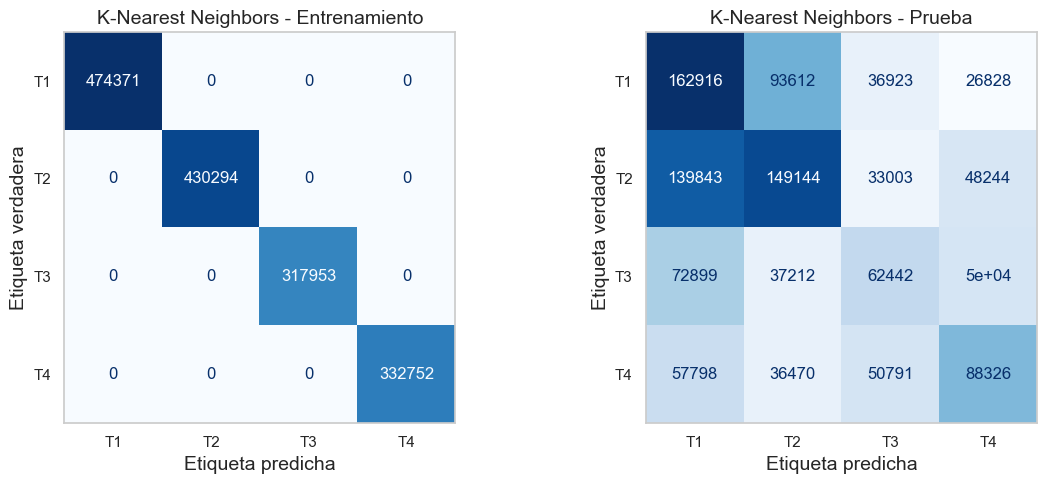

In [98]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
tratamiento_labels = ['T1', 'T2', 'T3', 'T4']

for ax, matriz, split in zip(
    axes,
    [knn_cm_train, knn_cm_test],
    ["Entrenamiento", "Prueba"],
):
    disp = ConfusionMatrixDisplay(confusion_matrix=matriz, display_labels=tratamiento_labels)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f"K-Nearest Neighbors - {split}", fontsize=14)
    ax.grid(False)
    ax.set_xlabel('Etiqueta predicha')
    ax.set_ylabel('Etiqueta verdadera')

plt.tight_layout()
plt.show()

## 8.3 Random Forest - Búsqueda de hiperparámetros

In [99]:
# Hiperparámetros que permiten mayor regularización
rf_param_grid = {
    'n_estimators': [100, 150],
    'max_depth': [5, 10, 15],             # Limita la profundidad máxima drásticamente
    'min_samples_split': [20, 50, 100],   # Requiere más muestras para crear una nueva rama
    'min_samples_leaf': [10, 20, 50],     # Requiere más muestras en los nodos finales
    'max_features': ['sqrt', 'log2']      # Usa solo un subconjunto de bandas por división
}

In [100]:
print("🔍 Iniciando búsqueda de hiperparámetros para Random Forest con muestra reducida...")
print(f"Muestra: {X_train_sample.shape[0]:,} registros")

try:
    search_start = time.time()
    # Usar muestra para búsqueda de hiperparámetros con GroupKFold
    rf_gridSearchCV = make_rand_grid_search(RandomForestClassifier(n_jobs=-1, random_state=12), rf_param_grid, gkf)
    rf_gridSearchCV.fit(X_train_sample, y_train_sample, groups=groups_sample)
    search_elapsed = time.time() - search_start

    print(f"⏱️ Tiempo búsqueda Random Forest: {search_elapsed:.2f} s ({search_elapsed/60:.2f} min)")
    
    # Guardar resultados de hiperparámetros
    save_path = save_model_and_params(
        model=rf_gridSearchCV,
        model_name="RandomForest",
        best_params=rf_gridSearchCV.best_params_,
        score=rf_gridSearchCV.best_score_,
        stage="hyperparameter_tuning"
    )
    
    print(f"✅ Búsqueda de hiperparámetros Random Forest completada exitosamente")
    print(f"Best Score: {rf_gridSearchCV.best_score_:.4f}")
    
except Exception as e:
    print(f"❌ Error durante búsqueda de hiperparámetros Random Forest: {e}")
    raise

🔍 Iniciando búsqueda de hiperparámetros para Random Forest con muestra reducida...
Muestra: 233,305 registros
⏱️ Tiempo búsqueda Random Forest: 605.27 s (10.09 min)
✅ Modelo RandomForest guardado en: models/maiz/hyperparameter_tuning/RandomForest_20260426_162130_v4.pkl
✅ Búsqueda de hiperparámetros Random Forest completada exitosamente
Best Score: 0.4251


In [101]:
print("🎯 Mejores parámetros encontrados para Random Forest:")
print(rf_gridSearchCV.best_params_)
print(f"Score de validación cruzada: {rf_gridSearchCV.best_score_:.4f}")

🎯 Mejores parámetros encontrados para Random Forest:
{'n_estimators': 150, 'min_samples_split': 50, 'min_samples_leaf': 20, 'max_features': 'sqrt', 'max_depth': 15}
Score de validación cruzada: 0.4251


In [102]:
# Ahora entrenar con dataset completo usando mejores parámetros
print(f"\n🚀 Entrenando Random Forest con dataset completo ({X_train_scaled.shape[0]:,} muestras)...")

# Crear modelo final con mejores parámetros
rf_final = RandomForestClassifier(n_jobs=-1, random_state=12, **rf_gridSearchCV.best_params_)
# rf_final = RandomForestClassifier(n_jobs=-1, random_state=12, **rf_best_params)
train_start = time.time()
rf_final.fit(X_train_scaled, y_train_resampled)
train_elapsed = time.time() - train_start

print(f"⏱️ Tiempo entrenamiento Random Forest final: {train_elapsed:.2f} s ({train_elapsed/60:.2f} min)")

# Guardar modelo final
final_save_path = save_model_and_params(
    model=rf_final,
    model_name="RandomForest_final",
    best_params=rf_gridSearchCV.best_params_,
    score=rf_gridSearchCV.best_score_,
    stage="best"
)

print("✅ Modelo Random Forest final entrenado y guardado")


🚀 Entrenando Random Forest con dataset completo (1,555,370 muestras)...
⏱️ Tiempo entrenamiento Random Forest final: 277.46 s (4.62 min)
✅ Modelo RandomForest_final guardado en: models/maiz/best/RandomForest_final_20260426_162608_v4.pkl
✅ Modelo Random Forest final entrenado y guardado


### 8.3.1 Predicción

In [103]:
rf_y_test_pred = rf_final.predict(X_test_scaled)

In [104]:
rf_y_train_pred = rf_final.predict(X_train_scaled)

#### Guardar predicción

In [105]:
joblib.dump(rf_y_test_pred, "results/predictions/maiz/test/best_predicciones_rf_test_v4.pkl")

['results/predictions/maiz/test/best_predicciones_rf_test_v4.pkl']

In [106]:
joblib.dump(rf_y_train_pred, "results/predictions/maiz/train/best_predicciones_rf_train_v4.pkl")

['results/predictions/maiz/train/best_predicciones_rf_train_v4.pkl']

#### Cargar predicciones

In [24]:
rf_y_test_pred = joblib.load('results/predictions/maiz/test/best_predicciones_rf_test_2.pkl')

In [25]:
rf_y_train_pred = joblib.load('results/predictions/maiz/train/best_predicciones_rf_train_2.pkl')

### 8.3.2 Resultados

In [107]:
print("=" * 50)
print("Clasification Report - Entrenamiento")
print("=" * 50)
print(classification_report(y_train_resampled, rf_y_train_pred))

print("\n" + "=" * 50)
print("Clasification Report - Prueba")
print("=" * 50)
print(classification_report(y_test, rf_y_test_pred))

Clasification Report - Entrenamiento
              precision    recall  f1-score   support

           1       0.63      0.76      0.69    474371
           2       0.73      0.63      0.67    430294
           3       0.67      0.43      0.52    317953
           4       0.60      0.73      0.66    332752

    accuracy                           0.65   1555370
   macro avg       0.66      0.64      0.64   1555370
weighted avg       0.66      0.65      0.64   1555370


Clasification Report - Prueba
              precision    recall  f1-score   support

           1       0.41      0.53      0.46    320279
           2       0.52      0.43      0.47    370234
           3       0.38      0.19      0.25    222499
           4       0.44      0.60      0.51    233385

    accuracy                           0.45   1146397
   macro avg       0.44      0.44      0.42   1146397
weighted avg       0.45      0.45      0.43   1146397



In [108]:
rf_cm_train = confusion_matrix(
    y_true=y_train_resampled,
    y_pred=rf_y_train_pred,
    labels=None,
    normalize=None,
)

In [109]:
rf_cm_test = confusion_matrix(
    y_true=y_test,
    y_pred=rf_y_test_pred,
    labels=None,
    normalize=None,
)

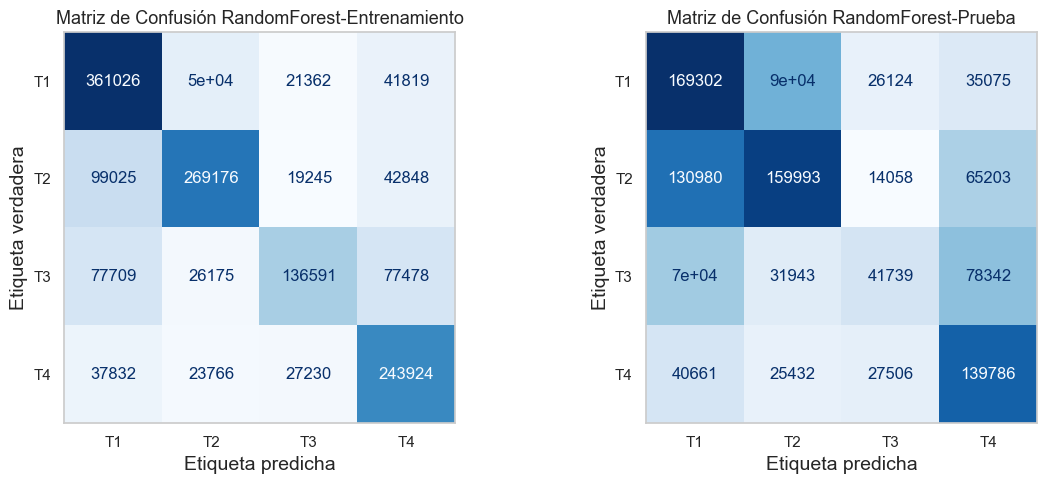

In [110]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
tratamiento_labels = ['T1', 'T2', 'T3', 'T4']

for ax, matriz, split in zip(
    axes,
    [rf_cm_train, rf_cm_test],
    ["Entrenamiento", "Prueba"],
):
    disp = ConfusionMatrixDisplay(confusion_matrix=matriz, display_labels=tratamiento_labels)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Matriz de Confusión RandomForest-{split}', fontsize=13)
    ax.grid(False)
    ax.set_xlabel('Etiqueta predicha')
    ax.set_ylabel('Etiqueta verdadera')

plt.tight_layout()
plt.show()

## 8.4 XGB - Búsqueda de hiperparámetros

In [111]:
# Hieprparámetros que permiten mayor regularización
xgb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],               # Árboles enanos obligan a buscar patrones fuertes
    'learning_rate': [0.01, 0.05, 0.1],   # Aprendizaje más lento
    'subsample': [0.6, 0.8],              # Usa solo un % de los píxeles en cada árbol
    'colsample_bytree': [0.6, 0.8],       # Usa solo un % de las bandas en cada árbol
    'reg_lambda': [1, 10, 50],            # Regularización L2: penaliza pesos altos
    'gamma': [0, 1, 5]                    # Requiere una ganancia mínima de pérdida para dividir
}

In [112]:
print("🔍 Iniciando búsqueda de hiperparámetros para XGBoost con muestra reducida...")
print(f"Muestra: {X_train_sample.shape[0]:,} registros")

try:
    search_start = time.time()
    # Usar muestra para búsqueda de hiperparámetros con GroupKFold
    xgb_gridSearchCV = make_rand_grid_search(xgb.XGBClassifier(random_state=42), xgb_param_grid, gkf)
    xgb_gridSearchCV.fit(X_train_sample, y_train_sample_encoded, groups=groups_sample)
    search_elapsed = time.time() - search_start

    print(f"⏱️ Tiempo búsqueda XGBoost: {search_elapsed:.2f} s ({search_elapsed/60:.2f} min)")
    
    # Guardar resultados de hiperparámetros
    save_path = save_model_and_params(
        model=xgb_gridSearchCV,
        model_name="XGBoost",
        best_params=xgb_gridSearchCV.best_params_,
        score=xgb_gridSearchCV.best_score_,
        stage="hyperparameter_tuning"
    )
    
    print(f"✅ Búsqueda de hiperparámetros XGBoost completada exitosamente")
    print(f"Best Score: {xgb_gridSearchCV.best_score_:.4f}")
    
except Exception as e:
    print(f"❌ Error durante búsqueda de hiperparámetros XGBoost: {e}")
    raise

🔍 Iniciando búsqueda de hiperparámetros para XGBoost con muestra reducida...
Muestra: 233,305 registros
⏱️ Tiempo búsqueda XGBoost: 208.63 s (3.48 min)
✅ Modelo XGBoost guardado en: models/maiz/hyperparameter_tuning/XGBoost_20260426_163056_v4.pkl
✅ Búsqueda de hiperparámetros XGBoost completada exitosamente
Best Score: 0.4218


In [113]:
print("🎯 Mejores parámetros encontrados para XGB:")
print(xgb_gridSearchCV.best_params_)
print(f"Score de validación cruzada: {xgb_gridSearchCV.best_score_:.4f}")

print(f"\n🚀 Entrenando XGBoost con dataset completo ({X_train_scaled.shape[0]:,} muestras)...")

# Crear modelo final con mejores parámetros
xgb_final = xgb.XGBClassifier(random_state=42, **xgb_gridSearchCV.best_params_)
train_start = time.time()
xgb_final.fit(X_train_scaled, y_train_encoded)
train_elapsed = time.time() - train_start
print(f"⏱️ Tiempo entrenamiento XGBoost final: {train_elapsed:.2f} s ({train_elapsed/60:.2f} min)")

# Guardar modelo final
final_save_path = save_model_and_params(
    model=xgb_final,
    model_name="XGBoost_final",
    best_params=xgb_gridSearchCV.best_params_,
    score=xgb_gridSearchCV.best_score_,
    stage="best"
)

print("✅ Modelo XGBoost final entrenado y guardado")

🎯 Mejores parámetros encontrados para XGB:
{'subsample': 0.8, 'reg_lambda': 50, 'n_estimators': 100, 'max_depth': 7, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 0.6}
Score de validación cruzada: 0.4218

🚀 Entrenando XGBoost con dataset completo (1,555,370 muestras)...
⏱️ Tiempo entrenamiento XGBoost final: 58.14 s (0.97 min)
✅ Modelo XGBoost_final guardado en: models/maiz/best/XGBoost_final_20260426_163155_v4.pkl
✅ Modelo XGBoost final entrenado y guardado


### 8.4.1 Predicción

In [114]:
xgb_y_test_pred = xgb_final.predict(X_test_scaled)

In [115]:
xgb_y_train_pred = xgb_final.predict(X_train_scaled)

#### Guardar predicciones

In [116]:
joblib.dump(xgb_y_test_pred, "results/predictions/maiz/test/best_predicciones_xgb_test_v4.pkl")

['results/predictions/maiz/test/best_predicciones_xgb_test_v4.pkl']

In [117]:
joblib.dump(xgb_y_train_pred, "results/predictions/maiz/train/best_predicciones_xgb_train_v4.pkl")

['results/predictions/maiz/train/best_predicciones_xgb_train_v4.pkl']

#### Cargar predicciones

In [ ]:
xgb_y_test_pred = joblib.load('results/predictions/maiz/test/best_predicciones_xgb_test_v4.pkl')

In [ ]:
xgb_y_train_pred = joblib.load('results/predictions/maiz/train/best_predicciones_xgb_train_v4.pkl')

### 8.4.2 Resultados

In [118]:
print("=" * 50)
print("Clasification Report - Entrenamiento")
print("=" * 50)
print(classification_report(y_train_encoded, xgb_y_train_pred))

print("\n" + "=" * 50)
print("Clasification Report - Prueba")
print("=" * 50)
print(classification_report(y_test_encoded, xgb_y_test_pred))

Clasification Report - Entrenamiento
              precision    recall  f1-score   support

           0       0.60      0.71      0.65    474371
           1       0.67      0.58      0.62    430294
           2       0.57      0.40      0.47    317953
           3       0.58      0.68      0.62    332752

    accuracy                           0.61   1555370
   macro avg       0.60      0.59      0.59   1555370
weighted avg       0.61      0.61      0.60   1555370


Clasification Report - Prueba
              precision    recall  f1-score   support

           0       0.41      0.51      0.45    320279
           1       0.51      0.45      0.48    370234
           2       0.33      0.19      0.24    222499
           3       0.44      0.55      0.49    233385

    accuracy                           0.44   1146397
   macro avg       0.42      0.43      0.42   1146397
weighted avg       0.43      0.44      0.43   1146397



In [119]:
xgb_cm_train = confusion_matrix(
    y_true=y_train_encoded,
    y_pred=xgb_y_train_pred,
    labels=None,
    normalize=None,
)

In [120]:
xgb_cm_test = confusion_matrix(
    y_true=y_test_encoded,
    y_pred=xgb_y_test_pred,
    labels=None,
    normalize=None,
)

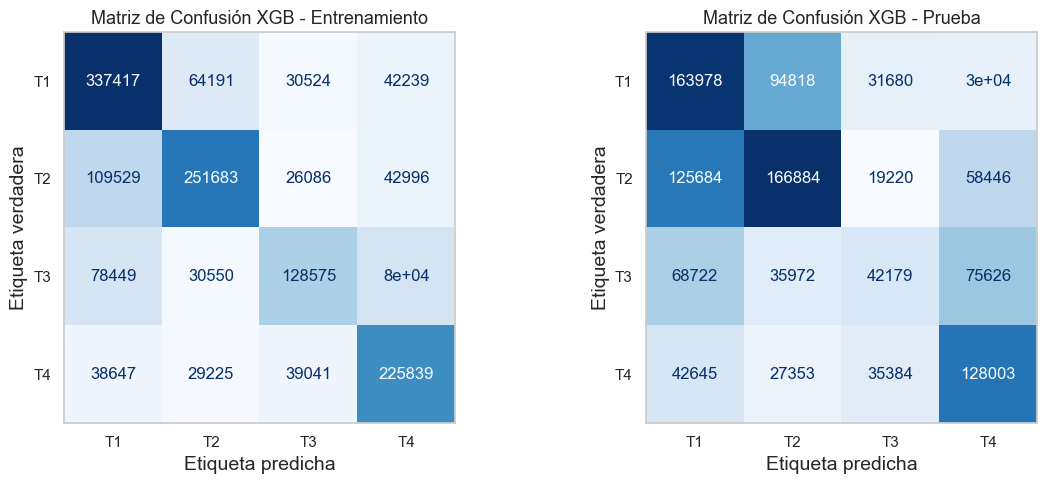

In [121]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
tratamiento_labels = ['T1', 'T2', 'T3', 'T4']

for ax, matriz, split in zip(
    axes,
    [xgb_cm_train, xgb_cm_test],
    ["Entrenamiento", "Prueba"],
):
    disp = ConfusionMatrixDisplay(confusion_matrix=matriz, display_labels=tratamiento_labels)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Matriz de Confusión XGB - {split}', fontsize=13)
    ax.grid(False)
    ax.set_xlabel('Etiqueta predicha')
    ax.set_ylabel('Etiqueta verdadera')

plt.tight_layout()
plt.show()

## 8.5 MLP - Búsqueda de hiperparámetros

In [122]:
mlp_param_grid = [
    {
        'hidden_layer_sizes': [(100,100,100), (128, 64, 32)], 
        'batch_size': [256],
        'learning_rate_init': [0.001],
        'alpha': [1e-4],
        'early_stopping' : [True]
    }
]

In [123]:
print("🔍 Iniciando búsqueda de hiperparámetros para MLP con muestra reducida...")
print(f"Muestra: {X_train_sample.shape[0]:,} registros")

try:
    search_start = time.time()
    # Usar muestra para búsqueda de hiperparámetros con GroupKFold
    mlp_gridSearchCV = make_rand_grid_search(MLPClassifier(), mlp_param_grid, gkf)
    mlp_gridSearchCV.fit(X_train_sample, y_train_sample, groups=groups_sample)
    search_elapsed = time.time() - search_start

    print(f"⏱️ Tiempo búsqueda MLP: {search_elapsed:.2f} s ({search_elapsed/60:.2f} min)")
    
    # Guardar resultados de hiperparámetros
    save_path = save_model_and_params(
        model=mlp_gridSearchCV,
        model_name="MLP",
        best_params=mlp_gridSearchCV.best_params_,
        score=mlp_gridSearchCV.best_score_,
        stage="hyperparameter_tuning"
    )
    
    print(f"✅ Búsqueda de hiperparámetros MLP completada exitosamente")
    print(f"Best Score: {mlp_gridSearchCV.best_score_:.4f}")
    
except Exception as e:
    print(f"❌ Error durante búsqueda de hiperparámetros MLP: {e}")
    raise

🔍 Iniciando búsqueda de hiperparámetros para MLP con muestra reducida...
Muestra: 233,305 registros
⏱️ Tiempo búsqueda MLP: 26291.75 s (438.20 min)
✅ Modelo MLP guardado en: models/maiz/hyperparameter_tuning/MLP_20260426_235032_v4.pkl
✅ Búsqueda de hiperparámetros MLP completada exitosamente
Best Score: 0.4304


In [124]:
print("🎯 Mejores parámetros encontrados para MLP:")
print(mlp_gridSearchCV.best_params_)
print(f"Score de validación cruzada: {mlp_gridSearchCV.best_score_:.4f}")

🎯 Mejores parámetros encontrados para MLP:
{'learning_rate_init': 0.001, 'hidden_layer_sizes': (128, 64, 32), 'early_stopping': True, 'batch_size': 256, 'alpha': 0.0001}
Score de validación cruzada: 0.4304


In [125]:
# Ahora entrenar con dataset completo usando mejores parámetros
print(f"\n🚀 Entrenando MLP con dataset completo ({X_train_scaled.shape[0]:,} muestras)...")

# Crear modelo final con mejores parámetros
mlp_final = MLPClassifier(**mlp_gridSearchCV.best_params_)
train_start = time.time()
mlp_final.fit(X_train_scaled, y_train_resampled)
train_elapsed = time.time() - train_start

print(f"⏱️ Tiempo entrenamiento MLP final: {train_elapsed:.2f} s ({train_elapsed/60:.2f} min)")

# Guardar modelo final
final_save_path = save_model_and_params(
    model=mlp_final,
    model_name="MLP_final",
    best_params=mlp_gridSearchCV.best_params_,
    score=mlp_gridSearchCV.best_score_,
    stage="best"
)

print("✅ Modelo MLP final entrenado y guardado")


🚀 Entrenando MLP con dataset completo (1,555,370 muestras)...
⏱️ Tiempo entrenamiento MLP final: 8457.16 s (140.95 min)
✅ Modelo MLP_final guardado en: models/maiz/best/MLP_final_20260427_021130_v4.pkl
✅ Modelo MLP final entrenado y guardado


### 8.5.1 Predicciones

In [126]:
mlp_y_test_pred = mlp_final.predict(X_test_scaled)

In [127]:
mlp_y_train_pred = mlp_final.predict(X_train_scaled)

#### Guardar predicciones

In [128]:
joblib.dump(mlp_y_test_pred, "results/predictions/maiz/test/best_predicciones_mlp_test_v4.pkl")

['results/predictions/maiz/test/best_predicciones_mlp_test_v4.pkl']

In [129]:
joblib.dump(mlp_y_train_pred, "results/predictions/maiz/train/best_predicciones_mlp_train_v4.pkl")

['results/predictions/maiz/train/best_predicciones_mlp_train_v4.pkl']

#### Cargar predicciones

In [35]:
mlp_y_test_pred = joblib.load('results/predictions/maiz/test/best_predicciones_mlp_test.pkl')

In [36]:
mlp_y_train_pred = joblib.load('results/predictions/maiz/train/best_predicciones_mlp_train.pkl')

### 8.5.2 Resultados

In [130]:
print("=" * 50)
print("Clasification Report - Entrenamiento")
print("=" * 50)
print(classification_report(y_train_resampled, mlp_y_train_pred))

print("\n" + "=" * 50)
print("Clasification Report - Prueba")
print("=" * 50)
print(classification_report(y_test, mlp_y_test_pred))

Clasification Report - Entrenamiento
              precision    recall  f1-score   support

           1       0.70      0.69      0.69    474371
           2       0.69      0.69      0.69    430294
           3       0.63      0.56      0.60    317953
           4       0.64      0.73      0.68    332752

    accuracy                           0.67   1555370
   macro avg       0.67      0.67      0.67   1555370
weighted avg       0.67      0.67      0.67   1555370


Clasification Report - Prueba
              precision    recall  f1-score   support

           1       0.43      0.45      0.44    320279
           2       0.49      0.46      0.48    370234
           3       0.35      0.27      0.31    222499
           4       0.43      0.52      0.47    233385

    accuracy                           0.44   1146397
   macro avg       0.43      0.43      0.42   1146397
weighted avg       0.43      0.44      0.43   1146397



In [131]:
mlp_cm_train = confusion_matrix(
    y_true=y_train_resampled,
    y_pred=mlp_y_train_pred,
    labels=None,
    normalize=None,
)

mlp_cm_test = confusion_matrix(
    y_true=y_test,
    y_pred=mlp_y_test_pred,
    labels=None,
    normalize=None,
)

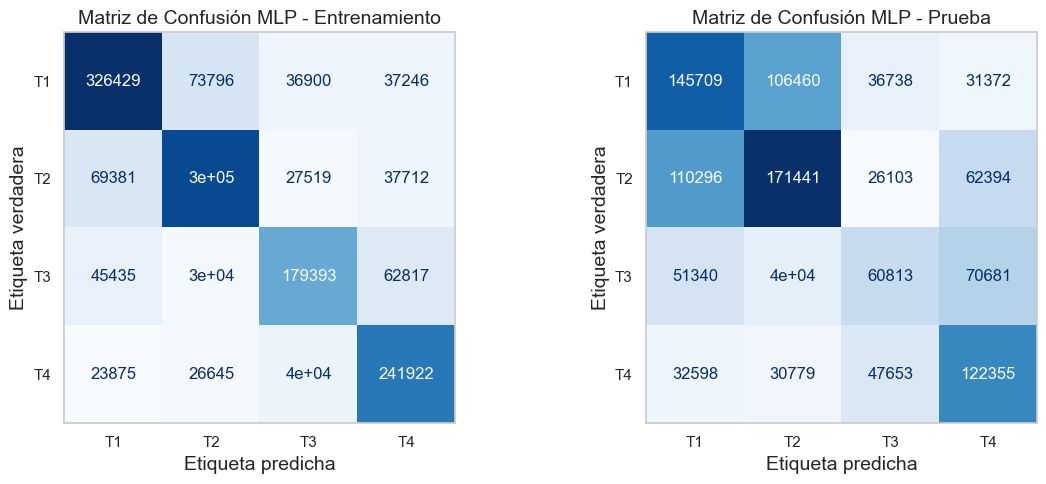

In [132]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
tratamiento_labels = ['T1', 'T2', 'T3', 'T4']

for ax, matriz, split in zip(
    axes,
    [mlp_cm_train, mlp_cm_test],
    ["Entrenamiento", "Prueba"],
):
    disp = ConfusionMatrixDisplay(confusion_matrix=matriz, display_labels=tratamiento_labels)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Matriz de Confusión MLP - {split}', fontsize= 14)
    ax.grid(False)
    ax.set_xlabel('Etiqueta predicha')
    ax.set_ylabel('Etiqueta verdadera')

plt.tight_layout()
plt.show()

## 8.6 Evaluación de modelos optimizados

In [133]:
classifiers_names = ["knn", "rfc", "xgb", "mlp"]

In [134]:
predictions_train = [knn_y_train_pred, rf_y_train_pred, xgb_y_train_pred, mlp_y_train_pred]

In [135]:
predictions_test = [knn_y_test_pred, rf_y_test_pred, xgb_y_test_pred, mlp_y_test_pred]

Comparativo de métricas entrenamiento

In [136]:
results_list = []

for preds, classifier_name in zip(predictions_train, classifiers_names):

    if classifier_name=='xgb':
        report_dict = classification_report(y_train_encoded, preds, output_dict=True)
    else:
        report_dict = classification_report(y_train_resampled, preds, output_dict=True)
    
    precision = report_dict['weighted avg']['precision']
    recall = report_dict['weighted avg']['recall']
    f1_score = report_dict['weighted avg']['f1-score']
    accuracy = report_dict['accuracy'] 

    # Kappa
    if classifier_name=='xgb':
        kappa = cohen_kappa_score(y_train_encoded, preds)
    else:
        kappa = cohen_kappa_score(y_train_resampled, preds)
    
    results_list.append({
        'Modelo': classifier_name,
        'Accuracy': accuracy,
        'Precision (Ponderada)': precision,
        'Recall (Ponderado)': recall,
        'F1-Score (Ponderado)': f1_score,
        'Kappa Score': kappa
    })

results_df = pd.DataFrame(results_list)

results_df = results_df.set_index('Modelo')

display(results_df.style.background_gradient(cmap='summer_r', axis=0))

,Accuracy,Precision (Ponderada),Recall (Ponderado),F1-Score (Ponderado),Kappa Score
Modelo,,,,,
knn,1.000000,1.000000,1.000000,1.000000,1.000000
rfc,0.649824,0.658052,0.649824,0.644175,0.525975
xgb,0.606617,0.608448,0.606617,0.601376,0.467876
mlp,0.670854,0.671253,0.670854,0.670010,0.557229


Comparativo de métricas testing

In [137]:
results_list = []

for preds, classifier_name in zip(predictions_test, classifiers_names):

    if classifier_name=='xgb':
        report_dict = classification_report(y_test_encoded, preds, output_dict=True)
    else:
        report_dict = classification_report(y_test, preds, output_dict=True)
    
    precision = report_dict['weighted avg']['precision']
    recall = report_dict['weighted avg']['recall']
    f1_score = report_dict['weighted avg']['f1-score']
    accuracy = report_dict['accuracy'] 

    # Kappa
    if classifier_name=='xgb':
        kappa = cohen_kappa_score(y_test_encoded, preds)
    else:
        kappa = cohen_kappa_score(y_test, preds)
    
    results_list.append({
        'Modelo': classifier_name,
        'Accuracy': accuracy,
        'Precision (Ponderada)': precision,
        'Recall (Ponderado)': recall,
        'F1-Score (Ponderado)': f1_score,
        'Kappa Score': kappa
    })

results_df = pd.DataFrame(results_list)

results_df = results_df.set_index('Modelo')

display(results_df.style.background_gradient(cmap='summer_r', axis=0))

,Accuracy,Precision (Ponderada),Recall (Ponderado),F1-Score (Ponderado),Kappa Score
Modelo,,,,,
knn,0.403724,0.407672,0.403724,0.401316,0.190201
rfc,0.445587,0.446601,0.445587,0.433805,0.248906
xgb,0.437060,0.433062,0.437060,0.427936,0.236301
mlp,0.436426,0.434445,0.436426,0.433132,0.237475
